## Описание файла

Данный ноутбук содержит серию экспериментов по построению системы визуального поиска похожих товаров на основе метрического обучения. Проводится сравнение архитектур бекбонов (ResNet, EfficientNet, DINOv2, Swin), типов глобального пулинга (GeM, Avg, Max), функций потерь (ArcFace, SubCenter ArcFace), гиперпараметров (scale, margin, learning rate, weight decay), а также ансамблей. Финальная часть включает автоматический подбор гиперпараметров с помощью Optuna.

Все результаты сохраняются в `experiment_results.csv` для последующего анализа и визуализации.

### Установка и зависимости

Необходимы библиотеки: `torch`, `timm`, `pytorch_metric_learning`, `faiss-cpu` (или `faiss-gpu`), `albumentations`, `pandas`, `numpy`, `opencv-python`, `matplotlib`, `scikit-learn`, `tqdm`, `optuna`, `joblib`.

### Инструкция по использованию

1. **Пути к данным:** По умолчанию скрипт ищет данные в `/kaggle/input/competitions/shopee-product-matching/`. Если вы запускаете код локально, измените `BASE_DIR` в классе `Config`.
2. **Конфигурация:** Все ключевые параметры (размер изображения, гиперпараметры ArcFace, размер батча, seed, learning rate) сосредоточены в классе `Config` в начале скрипта.

## Импорт библиотек и конфиг

In [1]:
import gc
import os
import random
import sys
import time
from contextlib import nullcontext
from typing import Dict, List, Optional, Tuple

import albumentations as A
import cv2
import faiss
import matplotlib.pyplot as plt
import numpy as np
import optuna
import pandas as pd
import plotly.io as pio
import seaborn as sns
import timm
import torch
import torch.nn as nn
import torch.nn.functional as F
from albumentations.pytorch import ToTensorV2
from optuna.pruners import MedianPruner
from optuna.samplers import TPESampler
from pytorch_metric_learning import losses
from pytorch_metric_learning.losses import SubCenterArcFaceLoss
from sklearn.decomposition import PCA
from sklearn.model_selection import GroupShuffleSplit
from sklearn.preprocessing import LabelEncoder
from torch.utils.data import DataLoader, Dataset
from tqdm import tqdm

In [2]:
class Config:
    BASE_DIR = '/kaggle/input/competitions/shopee-product-matching/'
    CSV_PATH = f'{BASE_DIR}train.csv'
    IMAGE_DIR = f'{BASE_DIR}train_images/'
    RESULTS_FILE = 'experiment_results.csv'
    DATASET_MEAN_COLOR = (192, 183, 178) # для mean-padding, вычисленно в eda
    IMG_SIZE = 336
    BATCH_SIZE = 32
    GRAD_ACCUM = 4 # так как эксперементы на одной видео карте
    LR = 1e-4
    WEIGHT_DECAY = 1e-4
    ARC_MARGIN = 28.6
    ARC_SCALE = 64.0
    SEED = 42
    TRAIN_SIZE = 0.70
    VAL_SIZE   = 0.15
    TEST_SIZE  = 0.15
    NUM_WORKERS = 4
    DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [3]:
# Фиксируем все источники случайности для воспроизводимости
random.seed(Config.SEED)
np.random.seed(Config.SEED)
torch.manual_seed(Config.SEED)
A.core.composition.SEED = Config.SEED
if torch.cuda.is_available():
    torch.cuda.manual_seed(Config.SEED)
os.environ['PYTHONHASHSEED'] = str(Config.SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

## Функции и классы

In [4]:
def load_results():
    if os.path.exists(Config.RESULTS_FILE):
        return pd.read_csv(Config.RESULTS_FILE)
    else:
        return pd.DataFrame()

def save_results(df):
    df.to_csv(Config.RESULTS_FILE, index=False)

In [5]:
def preprocess_data(
    csv_path: str,
    image_dir: str,
    train_size: float = 0.70,
    val_size: float = 0.15,
    test_size: float = 0.15,
    random_state: int = 42
) -> Tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame, int]:
    """
    Загружает и предобрабатывает данные Shopee.
    Этапы:
        1. Загрузка CSV и добавление полного пути к изображениям.
        2. Очистка данных:
           - удаление полных дубликатов (image_phash, label_group)
           - удаление строк с конфликтующими метками (один phash в разных группах)
           - удаление групп, в которых осталось менее 2 изображений
        3. Label Encoding для label_group.
        4. Разделение на train/val/test с сохранением целостности групп.
    """
    # Загрузка
    df = pd.read_csv(csv_path)
    df['image_path'] = df['image'].apply(lambda x: os.path.join(image_dir, x))
    
    # Очистка данных
    initial_len = len(df)
    # Удаляем точные дубликаты (одинаковые phash и группа)
    df = df.drop_duplicates(subset=['image_phash', 'label_group'], keep='first')
    print(f"Удалено полных дубликатов: {initial_len - len(df)}")
    
    # Удаляем конфликтующие записи: один phash, но разные группы
    tmp = df.groupby('image_phash')['label_group'].nunique()
    conflicting = tmp[tmp > 1].index
    if len(conflicting) > 0:
        pre_conf = len(df)
        df = df[~df['image_phash'].isin(conflicting)]
        print(f"Удалено конфликтующих записей: {pre_conf - len(df)}")
    else:
        print("Конфликтов не обнаружено.")
    
    # Удаляем группы, в которых меньше 2 изображений (нельзя обучить метрику)
    pre_single = len(df)
    group_counts = df['label_group'].value_counts()
    keep_groups = group_counts[group_counts >= 2].index
    df = df[df['label_group'].isin(keep_groups)].reset_index(drop=True)
    print(f"Удалено одиночных групп: {pre_single - len(df)}")
    print(f"Итоговый размер после очистки: {len(df)} (было {initial_len})")
    
    # Кодируем метки групп в целые числа
    le = LabelEncoder()
    df['label'] = le.fit_transform(df['label_group'])
    num_classes = df['label'].nunique()
    print(f"Уникальных групп товаров: {num_classes}")
    
    # Разделение на train/val/test с сохранением групп
    total = train_size + val_size + test_size
    assert abs(total - 1.0) < 1e-6, "Сумма долей должна быть 1.0"
    
    gss1 = GroupShuffleSplit(n_splits=1, test_size=val_size + test_size, random_state=random_state)
    train_idx, temp_idx = next(gss1.split(df, groups=df['label_group']))
    train_df = df.iloc[train_idx].reset_index(drop=True)
    temp_df = df.iloc[temp_idx].reset_index(drop=True)
    
    test_frac = test_size / (val_size + test_size)
    gss2 = GroupShuffleSplit(n_splits=1, test_size=test_frac, random_state=random_state)
    val_idx, test_idx = next(gss2.split(temp_df, groups=temp_df['label_group']))
    val_df = temp_df.iloc[val_idx].reset_index(drop=True)
    test_df = temp_df.iloc[test_idx].reset_index(drop=True)
    
    print(f"Train: {len(train_df)} ({train_df['label_group'].nunique()} групп)")
    print(f"Val:   {len(val_df)} ({val_df['label_group'].nunique()} групп)")
    print(f"Test:  {len(test_df)} ({test_df['label_group'].nunique()} групп)")
    
    return train_df, val_df, test_df, num_classes

In [6]:
class ShopeeDataset(Dataset):
    """PyTorch Dataset для загрузки изображений с применением аугментаций."""
    def __init__(self, df, transforms=None):
        self.df = df
        self.transforms = transforms

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = cv2.imread(row['image_path'])
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        if self.transforms:
            img = self.transforms(image=img)['image']
        label = torch.tensor(row['label'], dtype=torch.long)
        return img, label

In [7]:
def get_embeddings(
    model: nn.Module,
    loader: DataLoader
) -> Tuple[np.ndarray, np.ndarray]:
    """
    Извлекает L2-нормализованные эмбеддинги для всех объектов из loader, используя переданную модель
    """
    model.eval()
    device = next(model.parameters()).device # Устройство, на котором находится модель
    all_embs, all_labels = [], []
    # Определяем, нужно ли показывать прогресс-бар
    with torch.inference_mode():
        # Добавляем file=sys.stdout, чтобы синхронизировать вывод с обычным print
        with tqdm(loader, desc="Embed", leave=False, file=sys.stdout) as pbar:
            for images, labels in pbar:
                images = images.to(device, non_blocking=True)
                # Используем автоматическое смешанное точное вычисление (AMP) с bfloat16
                if torch.cuda.is_available() and torch.cuda.is_bf16_supported():
                    with torch.amp.autocast('cuda', dtype=torch.bfloat16):
                        feats = model(images)
                else:
                    feats = model(images)
                # Нормализуем эмбеддинги к единичной L2-норме
                feats = F.normalize(feats.float(), p=2, dim=1)
                # Перемещаем результат на CPU и добавляем в список
                all_embs.append(feats.cpu())
                all_labels.append(labels)
    # Конкатенируем все части в единые тензоры
    embs = torch.cat(all_embs, dim=0).numpy()
    labels = torch.cat(all_labels, dim=0).numpy()
    return embs, labels

In [8]:
def compute_gap_slow(
    embs_norm: np.ndarray,
    labels: np.ndarray
) -> float:
    """
    Вычисляет разность между средним внутриклассовым и средним межклассовым косинусным
    сходством для нормализованных эмбеддингов. Медленный CPU‑вариант для запасного случая.
    """
    n = embs_norm.shape[0]
    sim = embs_norm @ embs_norm.T
    intra_sim = []
    inter_sim = []
    for i in range(n):
        for j in range(i + 1, n):
            if labels[i] == labels[j]:
                intra_sim.append(sim[i, j])
            else:
                inter_sim.append(sim[i, j])
    mean_intra = np.mean(intra_sim) if intra_sim else 0.0
    mean_inter = np.mean(inter_sim) if inter_sim else 0.0
    return mean_intra - mean_inter

In [9]:
def fast_similarity_gap_gpu(
    embs_norm: np.ndarray,
    labels: np.ndarray,
    batch_size: int = 2048,
) -> float:
    """
    Быстрый расчёт разницы между средним внутриклассовым и межклассовым
    косинусным сходством на GPU. При невозможности – автоматический откат на CPU.
    """
    if not torch.cuda.is_available():
        return compute_gap_slow(embs_norm, labels)

    device = torch.device('cuda')
    try:
        embs = torch.from_numpy(embs_norm).to(device)
        lbls = torch.from_numpy(labels).to(device)
        n = embs.shape[0]
        intra_sum, inter_sum = 0.0, 0.0
        intra_cnt, inter_cnt = 0, 0
        for i in range(0, n, batch_size):
            batch_embs = embs[i : i + batch_size]
            batch_lbls = lbls[i : i + batch_size]
            # Матрица сходства [batch_size, n]
            sim = batch_embs @ embs.T
            # Маска совпадения классов
            is_same = (batch_lbls.view(-1, 1) == lbls.view(1, -1))
            # Индексы диагональных элементов в текущем батче
            diag_idx = torch.arange(i, min(i + batch_size, n), device=device)
            local_idx = torch.arange(len(batch_lbls), device=device)
            # Исключаем самосравнение (диагональ)
            is_same[local_idx, diag_idx] = False
            is_diff = ~is_same
            is_diff[local_idx, diag_idx] = False   # тоже убираем диагональ
            # Суммируем внутри- и межклассовые сходства
            intra_sum += sim[is_same].sum().item()
            intra_cnt += is_same.sum().item()
            inter_sum += sim[is_diff].sum().item()
            inter_cnt += is_diff.sum().item()
        intra_mean = intra_sum / intra_cnt if intra_cnt > 0 else 0.0
        inter_mean = inter_sum / inter_cnt if inter_cnt > 0 else 0.0
        return intra_mean - inter_mean
    except RuntimeError as e:
        if "CUDA out of memory" in str(e):
            torch.cuda.empty_cache()
            return compute_gap_slow(embs_norm, labels)
        raise e

In [10]:
def compute_metrics_from_embeddings(
    embs_norm: np.ndarray,
    labels: np.ndarray,
    recall_ks: List[int] = [1, 5, 10],
    map_ks: List[int] = [1, 5, 10]
) -> Dict[str, float]:
    """Вычисляет метрики качества эмбеддингов: Recall@k mAP@k, используя FAISS"""
    # Создаём FAISS-индекс для поиска по внутреннему произведению.
    n, d = embs_norm.shape
    index = faiss.IndexFlatIP(d)
    index.add(embs_norm)
    # Ищем для каждого образца max_k ближайших соседей.
    max_k = max(max(recall_ks), max(map_ks)) + 1
    _, I = index.search(embs_norm, max_k)
    metrics = {}
    # Подсчёт Recall@k
    for k in recall_ks:
        retrieved = labels[I[:, 1:k+1]] # индекс 0 – это сам запрос
        # Проверяем, есть ли среди этих k соседей хотя бы один с тем же классом, что у запроса
        hits = np.any(retrieved == labels[:, None], axis=1).sum()
        metrics[f'recall@{k}'] = hits / n
    # Подсчёт mAP@k
    for k in map_ks:
        retrieved = labels[I[:, 1:k+1]]  # индекс 0 – это сам запрос
        # Маска релевантности: True там, где метка соседа совпадает с меткой запроса
        relevant = (retrieved == labels[:, None])
        # Precision на каждом ранге: кумулятивная сумма релевантных, делённая на номер позиции
        prec = relevant.cumsum(axis=1) / np.arange(1, k+1)
        total_rel_all = np.bincount(labels)[labels] - 1
        total_rel = np.minimum(k, total_rel_all)
        # Average Precision для каждого запроса: сумма (precision * relevant) / total_rel
        ap = (prec * relevant).sum(axis=1) / np.maximum(total_rel, 1)
        # Mean Average Precision – среднее по всем запросам
        metrics[f'map@{k}'] = float(np.mean(ap))
    # Similarity Gap
    metrics['gap'] = fast_similarity_gap_gpu(embs_norm, labels)
    return metrics

In [11]:
class GeMPooling(nn.Module):
    """Generalised Mean Pooling с обучаемым параметром p."""
    def __init__(self, p=3.0, eps=1e-6):
        super().__init__()
        self.p = nn.Parameter(torch.ones(1) * p)
        self.eps = eps

    def forward(self, x):
        # x: (B, C, H, W)
        return F.avg_pool2d(
            x.clamp(min=self.eps).pow(self.p),
            (x.size(-2), x.size(-1))
        ).pow(1. / self.p).flatten(1)

In [12]:
def build_model(backbone_name='resnet50', pool_type='avg'):
    """
    Создаёт модель с заданным backbone и типом глобального пулинга.
    Поддерживает 'avg', 'max', 'gem'.
    """
    if pool_type in ('avg', 'max'):
        model = timm.create_model(backbone_name, pretrained=True, num_classes=0, global_pool=pool_type)
        return model
    elif pool_type == 'gem':
        backbone = timm.create_model(backbone_name, pretrained=True, num_classes=0, global_pool='')
        backbone = backbone.to(Config.DEVICE)
        # Размер эмбеддинга после backbone (без пулинга) — берём через dummy прогон, но пока захардкодим 2048 для resnet50
        # Лучше определить динамически
        dummy = torch.randn(2, 3, Config.IMG_SIZE, Config.IMG_SIZE).to(Config.DEVICE)
        with torch.no_grad():
            feat = backbone(dummy)
            # feat shape: (B, C, H, W) – нам нужен размер каналов C
            num_features = feat.size(1)
        gem = GeMPooling(p=3.0)
        proj = nn.Sequential(
            nn.Linear(num_features, num_features),
            nn.BatchNorm1d(num_features)
        )
        return nn.Sequential(backbone, gem, proj)
    else:
        raise ValueError(f"Unknown pool_type: {pool_type}")

In [13]:
class DinoWithProjector(nn.Module):
    def __init__(self, img_size=336, proj_dim=384):
        """Эмбеддер на основе DINOv2 ViT-S/14 с обучаемым проектором. Backbone заморожен и всегда находится в режиме eval – градиенты через него не текут."""
        super().__init__()
        # Предобученный DINOv2 без классификационной головы
        self.backbone = timm.create_model('vit_small_patch14_dinov2.lvd142m', pretrained=True, num_classes=0, img_size=img_size)
        # Замораживаем backbone
        for p in self.backbone.parameters():
            p.requires_grad = False
        # Backbone будет всегда в eval
        self.backbone.eval()

        self.proj = nn.Sequential(
            nn.Linear(384, proj_dim),
            nn.BatchNorm1d(proj_dim))

    def forward(self, x):
        feats = self.backbone(x)    
        return self.proj(feats)

    def train(self, mode=True):
        super().train(mode)
        self.backbone.eval()              # backbone всегда eval

In [14]:
class SwinWithProjector(nn.Module):
    """Эмбеддер на основе Swin Transformer с обучаемым проектором. Backbone не заморожен и может дообучаться."""    
    def __init__(self, backbone_name='swin_small_patch4_window7_224', img_size=336, proj_dim=768):
        super().__init__()
        # Создаём предобученный Swin Transformer без классификационного слоя
        self.backbone = timm.create_model(backbone_name, pretrained=True, num_classes=0, img_size=img_size,           # задаём целевой размер 336
                                          dynamic_img_pad=True)         # разрешаем адаптивный patch embed
        self.proj = nn.Sequential(
            nn.Linear(768, proj_dim),
            nn.BatchNorm1d(proj_dim))

    def forward(self, x):
        feats = self.backbone(x)
        return self.proj(feats)

In [15]:
class DinoWithProjectorUnfrozen(nn.Module):
    def __init__(self, img_size=336, proj_dim=384, unfreeze_blocks=2):
        """Эмбеддер на основе DINOv2 ViT-S/14 с частичной разморозкой последних блоков и обучаемым проектором."""
        super().__init__()
        # Предобученный DINOv2 без классификационной головы
        self.backbone = timm.create_model('vit_small_patch14_dinov2.lvd142m', pretrained=True, num_classes=0, img_size=img_size)
        
        for p in self.backbone.parameters():
            p.requires_grad = False

        # Размораживаем указанное количество последних блоков
        if unfreeze_blocks > 0:
            for block in self.backbone.blocks[-unfreeze_blocks:]:
                for p in block.parameters():
                    p.requires_grad = True

        self.proj = nn.Sequential(
            nn.Linear(384, proj_dim),
            nn.BatchNorm1d(proj_dim))

    def forward(self, x):
        feats = self.backbone(x)
        return self.proj(feats)

In [16]:
class SwinWithProjectorPartial(nn.Module):
    """Эмбеддер на основе Swin Transformer с возможностью выборочной заморозки стадий. По умолчанию patch_embed заморожен, а body может быть полностью или частично разморожен."""
    def __init__(self,backbone_name='swin_small_patch4_window7_224',img_size=336,proj_dim=768, freeze_stages=None): # список индексов стадий, которые нужно заморозить (0,1,2,3)
        super().__init__()
        # Создаём предобученный Swin Transformer без классификационной головы
        self.backbone = timm.create_model(backbone_name, pretrained=True, num_classes=0,img_size=img_size, dynamic_img_pad=True)

        for p in self.backbone.patch_embed.parameters():
            p.requires_grad = False

        # Выборочная заморозка целых стадий (Swin состоит из 4 стадий, layers[0..3])
        if freeze_stages is not None:
            for stage_idx in freeze_stages:
                for p in self.backbone.layers[stage_idx].parameters():
                    p.requires_grad = False

        self.proj = nn.Sequential(
            nn.Linear(768, proj_dim),
            nn.BatchNorm1d(proj_dim))

    def forward(self, x):
        feats = self.backbone(x)
        return self.proj(feats)

In [17]:
def lr_finder_fixed_groups(
    model: torch.nn.Module,
    loss_func: torch.nn.Module,
    train_loader: torch.utils.data.DataLoader,
    optimizer: torch.optim.Optimizer,
    vary_group_indices: List[int],
    start_lr: float = 1e-6,
    end_lr: float = 1e-1,
    num_steps: int = 200,
    skip_steps: int = 15
) -> Optional[pd.DataFrame]:
    """Поиск оптимального lr с возможностью изменять lr только у выбранных групп параметров оптимизатора.
    Запускает обучение на нескольких батчах, постепенно увеличивая lr, выводит график «loss vs LR» и значение lr с Max negative gradient"""
    model.train()
    # Сохраняем состояние модели для восстановления после теста
    torch.save(model.state_dict(), 'tmp_lr_finder.pth')

    initial_lrs = [optimizer.param_groups[i]['lr'] for i in vary_group_indices]
    lr_mult = (end_lr / start_lr) ** (1.0 / num_steps)

    results = []
    best_loss = float('inf')
    data_iter = iter(train_loader)

    for step in range(num_steps):
        # Получение следующего батча (по кругу, если данные кончились)
        try:
            images, labels = next(data_iter)
        except StopIteration:
            data_iter = iter(train_loader)
            images, labels = next(data_iter)

        images = images.to(Config.DEVICE, non_blocking=True)
        labels = labels.to(Config.DEVICE, non_blocking=True)

        # Текущий LR берём из первой варьируемой группы (они все меняются синхронно)
        current_lr = optimizer.param_groups[vary_group_indices[0]]['lr']

        optimizer.zero_grad()
        with torch.amp.autocast('cuda') if torch.cuda.is_available() else nullcontext():
            emb = model(images)
            loss = loss_func(emb, labels)
        loss.backward()
        optimizer.step()

        # Экспоненциально увеличиваем LR только для указанных групп
        for i in vary_group_indices:
            optimizer.param_groups[i]['lr'] *= lr_mult

        loss_val = loss.item()
        results.append({'lr': current_lr, 'loss': loss_val})

        # Ранняя остановка, если потери взлетели
        if loss_val < best_loss:
            best_loss = loss_val
        if loss_val > best_loss * 4.0 and step > 10:
            break

    # Восстановление исходного состояния модели и LR
    model.load_state_dict(torch.load('tmp_lr_finder.pth'))
    os.remove('tmp_lr_finder.pth')
    for i, init_lr in zip(vary_group_indices, initial_lrs):
        optimizer.param_groups[i]['lr'] = init_lr

    df = pd.DataFrame(results)
    if len(df) < 10:
        return None, None

    # Сглаживание потерь экспоненциальным скользящим средним
    beta = 0.98
    smoothed = []
    for i, loss in enumerate(df['loss']):
        if i == 0:
            s = loss
        else:
            s = beta * s + (1 - beta) * loss
        smoothed.append(s)
    df['smoothed_loss'] = smoothed

    # Поиск LR с самым крутым убыванием сглаженного лосса 
    if len(smoothed) > skip_steps:
        log_lr = np.log10(df['lr'].values)[skip_steps:]
        grad = np.gradient(smoothed[skip_steps:], log_lr)
        min_grad_idx = np.argmin(grad) + skip_steps
    else:
        log_lr = np.log10(df['lr'].values)
        grad = np.gradient(smoothed, log_lr)
        min_grad_idx = np.argmin(grad)
    best_lr = df.loc[min_grad_idx, 'lr']

    # График
    plt.figure(figsize=(10,5))
    plt.plot(df['lr'], smoothed, label='smoothed loss')
    plt.axvline(best_lr, color='red', linestyle='--', label=f'min gradient: {best_lr:.2e}')
    plt.xscale('log')
    plt.xlabel('LR')
    plt.ylabel('Smoothed Loss')
    plt.legend()
    plt.title('LR Finder')
    plt.show()

    print(f"Max negative gradient at lr = {best_lr:.2e}")
    return df

## Trainer

In [18]:
class Trainer:
    """Управляет обучением и валидацией модели с поддержкой DDP (распределённого обучения)."""
    def __init__(
        self,
        model: nn.Module,
        loss_func: losses.ArcFaceLoss,
        optimizer: torch.optim.Optimizer,
        experiment_name: str,
        scheduler = None,        
        accum_steps: int | None = None          
    ):
        self.model = model
        self.loss_func = loss_func
        self.optimizer = optimizer
        self.experiment_name = experiment_name
        self.scheduler = scheduler  

        self.accum_steps = accum_steps if accum_steps is not None else Config.GRAD_ACCUM

        self.device = Config.DEVICE
        self.accum_steps = Config.GRAD_ACCUM
        self.scaler = torch.amp.GradScaler('cuda') if torch.cuda.is_available() else None
        self.history = {'train_loss': [], 'val_recall1': [], 'val_map5': [], 'val_gap': []}

    def _run_batch(
        self, 
        images: torch.Tensor, 
        labels: torch.Tensor
    ) -> torch.Tensor:
        """Возвращает неусреднённый loss (без деления на accum_steps)."""
        if self.scaler is not None:
            with torch.amp.autocast('cuda'):
                emb = self.model(images)
                loss = self.loss_func(emb, labels)
        else:
            emb = self.model(images)
            loss = self.loss_func(emb, labels)
        return loss
        
    def _run_epoch(self, epoch: int) -> float:
        self.model.train()
        total_loss = 0.0
        self.optimizer.zero_grad()
        with tqdm(self.train_loader, desc=f"Epoch {epoch+1}/{self.max_epochs}", file=sys.stdout) as pbar:
            for step, (images, labels) in enumerate(pbar, start=1):
                images = images.to(self.device, non_blocking=True)
                labels = labels.to(self.device, non_blocking=True)
                loss = self._run_batch(images, labels) / self.accum_steps
                if self.scaler:
                    self.scaler.scale(loss).backward()
                else:
                    loss.backward()
                if step % self.accum_steps == 0:
                    if self.scaler:
                        self.scaler.step(self.optimizer)
                        self.scaler.update()
                    else:
                        self.optimizer.step()
                    self.optimizer.zero_grad()
                total_loss += loss.item() * self.accum_steps
                if step % 10 == 0 or step == len(self.train_loader):
                    pbar.set_postfix({'loss': loss.item() * self.accum_steps})
        # остаток
        if len(self.train_loader) % self.accum_steps != 0:
            if self.scaler:
                self.scaler.step(self.optimizer)
                self.scaler.update()
            else:
                self.optimizer.step()
            self.optimizer.zero_grad()
        avg_loss = total_loss / len(self.train_loader)
        self.history['train_loss'].append(avg_loss)
        print(f"Epoch {epoch+1} | Train Loss: {avg_loss:.4f}")
            
    def validate(self, epoch: int) -> None:
        """
        Выполняет валидацию модели: каждый процесс извлекает эмбеддинги для своей порции, затем результаты
        собираются и обрабатываются на процессе с рангом 0. Метрики вычисляются только на главном процессе
        """
        self.model.eval()
        val_embs, val_labels = get_embeddings(self.model, self.val_loader)  # уже L2-нормированные
        metrics = compute_metrics_from_embeddings(val_embs, val_labels, recall_ks=[1], map_ks=[5])
        r1, m5, gap = metrics['recall@1'], metrics['map@5'], metrics['gap']
        self.history['val_recall1'].append(r1)
        self.history['val_map5'].append(m5)
        self.history['val_gap'].append(gap)
        print(f"Epoch {epoch+1} | mAP@5: {m5:.4f} | Val Recall@1: {r1:.4f} | SimGap: {gap:.4f}")

    def train(
        self,         
        train_loader: DataLoader,
        val_loader: DataLoader, 
        max_epochs: int
    ) -> None:
        """Главный цикл обучения."""
        self.train_loader = train_loader
        self.val_loader = val_loader
        self.max_epochs = max_epochs 
        start = time.time()
        for ep in range(max_epochs):
            self._run_epoch(ep)
            self.validate(ep)
            self.training_time = time.time() - start
            self.save_results(epoch=ep+1)
            if self.scheduler is not None:
                self.scheduler.step()

    def save_results(self, epoch=None):
        if epoch is None:
            epoch = len(self.history['train_loss'])   # последняя эпоха
        row = {
            'experiment_name': self.experiment_name,
            'epoch': epoch,
            'total_epochs': self.max_epochs,
            'train_loss': self.history['train_loss'][epoch-1],
            'val_recall@1': self.history['val_recall1'][epoch-1],
            'val_map@5': self.history['val_map5'][epoch-1],
            'val_simgap': self.history['val_gap'][epoch-1],
            'training_time_sec': round(self.training_time, 1)
        }
        old = load_results()
        combined = pd.concat([old, pd.DataFrame([row])], ignore_index=True)
        save_results(combined)

## Подготовка данных

In [19]:
# Аугментации для обучения: изменяем размер без деформации (сохраняем пропорции),
# дополняем нулями до квадрата, затем небольшие искажения и нормализация
train_transforms = A.Compose([
    A.LongestMaxSize(max_size=Config.IMG_SIZE),
    A.PadIfNeeded(Config.IMG_SIZE, Config.IMG_SIZE, 
                  border_mode=cv2.BORDER_CONSTANT, fill = Config.DATASET_MEAN_COLOR),
    A.HorizontalFlip(p=0.5),
    A.RandomBrightnessContrast(p=0.2),
    A.Normalize(),
    ToTensorV2()
])

# Валидационные/тестовые трансформации: только приведение размера и нормализация
val_transforms = A.Compose([
    A.LongestMaxSize(max_size=Config.IMG_SIZE),
    A.PadIfNeeded(Config.IMG_SIZE, Config.IMG_SIZE, 
                  border_mode=cv2.BORDER_CONSTANT, fill = Config.DATASET_MEAN_COLOR),
    A.Normalize(),
    ToTensorV2()
])

In [20]:
train_df, val_df, test_df, num_classes = preprocess_data(
    csv_path=Config.CSV_PATH,
    image_dir=Config.IMAGE_DIR,
    train_size=Config.TRAIN_SIZE,
    val_size=Config.VAL_SIZE,
    test_size=Config.TEST_SIZE,
    random_state=Config.SEED
)

Удалено полных дубликатов: 5358
Удалено конфликтующих записей: 304
Удалено одиночных групп: 1090
Итоговый размер после очистки: 27498 (было 34250)
Уникальных групп товаров: 9901
Train: 19411 (6930 групп)
Val:   4113 (1485 групп)
Test:  3974 (1486 групп)


In [21]:
train_dataset = ShopeeDataset(train_df, train_transforms)
val_dataset = ShopeeDataset(val_df, val_transforms)

In [22]:
train_loader = DataLoader(
    train_dataset, 
    batch_size=Config.BATCH_SIZE, 
    shuffle=True, 
    num_workers=Config.NUM_WORKERS,
    pin_memory=True,
    persistent_workers=(Config.NUM_WORKERS > 0)
)
val_loader = DataLoader(
    val_dataset, 
    batch_size=Config.BATCH_SIZE*2, 
    shuffle=False, 
    num_workers=Config.NUM_WORKERS,
    pin_memory=True,
    persistent_workers=(Config.NUM_WORKERS > 0)
)

In [23]:
train_strong_transforms = A.Compose([
    A.RandomScale(scale_limit=(-0.3, 0), p=1.0),
    A.LongestMaxSize(max_size=Config.IMG_SIZE),              
    A.PadIfNeeded(min_height=Config.IMG_SIZE, min_width=Config.IMG_SIZE, 
                  border_mode=cv2.BORDER_CONSTANT, fill=Config.DATASET_MEAN_COLOR, position='random'),
    A.HorizontalFlip(p=0.5),
    A.RandomBrightnessContrast(brightness_limit=0.2, contrast_limit=0.2, p=0.5),
    A.HueSaturationValue(hue_shift_limit=10, sat_shift_limit=20, val_shift_limit=10, p=0.3),
    A.RandomGamma(gamma_limit=(80, 120), p=0.3),
    A.CoarseDropout(num_holes_range=(1, 1), hole_height_range=(0.1, 0.2),
                    hole_width_range=(0.1, 0.2), fill = Config.DATASET_MEAN_COLOR, p=0.3),
    A.Normalize(),
    ToTensorV2()
])

## GeM vs GAP vs Avg pooling

In [24]:
EXP_EPOCHS = 1

experiments = [
    (f'resnet50_avg_{EXP_EPOCHS}ep', 'avg'),
    (f'resnet50_max_{EXP_EPOCHS}ep', 'max'),
    (f'resnet50_gem_{EXP_EPOCHS}ep', 'gem')]

old_df = load_results()
done = set(old_df['experiment_name'].tolist()) if not old_df.empty else set()

for exp_name, pool_type in experiments:
    if exp_name in done:
        print(f"'{exp_name}' уже существует, пропускаем.")
        continue

    print(f"\n{'='*50}")
    print(f"Старт: {exp_name} (backbone=resnet50, pooling={pool_type})")

    # Сборка модели
    model = build_model('resnet50', pool_type).to(Config.DEVICE)

    # Определяем размер эмбеддинга
    dummy = torch.randn(2, 3, Config.IMG_SIZE, Config.IMG_SIZE).to(Config.DEVICE)
    with torch.no_grad():
        emb_dim = model(dummy).shape[1]

    # Функция потерь
    loss_func = losses.ArcFaceLoss(
        num_classes=num_classes,
        embedding_size=emb_dim,
        margin=Config.ARC_MARGIN,
        scale=Config.ARC_SCALE
    ).to(Config.DEVICE)

    # Оптимизатор
    optimizer = torch.optim.AdamW([
        {'params': model.parameters(), 'lr': Config.LR, 'weight_decay': Config.WEIGHT_DECAY},
        {'params': loss_func.parameters(), 'lr': Config.LR, 'weight_decay': 0.0}
    ])

    # Тренер и запуск
    trainer = Trainer(model, loss_func, optimizer, experiment_name=exp_name)
    trainer.train(train_loader, val_loader, EXP_EPOCHS)

    # Очистка GPU
    del model, loss_func, optimizer, trainer
    gc.collect()
    torch.cuda.empty_cache()


Старт: resnet50_avg_1ep (backbone=resnet50, pooling=avg)


model.safetensors:   0%|          | 0.00/102M [00:00<?, ?B/s]

Epoch 1/1: 100%|██████████| 607/607 [03:07<00:00,  3.24it/s, loss=40.6]
Epoch 1 | Train Loss: 40.6985
Epoch 1 | mAP@5: 0.4715 | Val Recall@1: 0.5427 | SimGap: 0.1633

Старт: resnet50_max_1ep (backbone=resnet50, pooling=max)
Epoch 1/1: 100%|██████████| 607/607 [03:06<00:00,  3.26it/s, loss=40.3]
Epoch 1 | Train Loss: 40.7380
Epoch 1 | mAP@5: 0.4771 | Val Recall@1: 0.5475 | SimGap: 0.1281

Старт: resnet50_gem_1ep (backbone=resnet50, pooling=gem)
Epoch 1/1: 100%|██████████| 607/607 [03:08<00:00,  3.21it/s, loss=39.2]
Epoch 1 | Train Loss: 40.1199
Epoch 1 | mAP@5: 0.5529 | Val Recall@1: 0.6156 | SimGap: 0.3689


In [25]:
# Таблица с результатами
df = load_results()
pool_names = [e[0] for e in experiments] # список имён экспериментов
table = df[df['experiment_name'].isin(pool_names)].copy()
table = table.round({'val_recall@1':4, 'val_map@5':4, 'val_simgap':4, 'training_time_sec':1})

# Выводим нужные колонки
cols = ['experiment_name', 'train_loss', 'val_recall@1', 'val_map@5', 'val_simgap', 'training_time_sec']
print(table[cols].to_string(index=False))

 experiment_name  train_loss  val_recall@1  val_map@5  val_simgap  training_time_sec
resnet50_avg_1ep   40.698492        0.5427     0.4715      0.1633              243.8
resnet50_max_1ep   40.737957        0.5475     0.4771      0.1281              241.9
resnet50_gem_1ep   40.119857        0.6156     0.5529      0.3689              244.2


### GeM с обучаемым p абсолютный лидер по метрикам и сепарабельности эмбеддингов.

## Backbone

In [26]:
EXP_EPOCHS = 1

experiments = [
    (f'effnet_b2_gem_{EXP_EPOCHS}ep',  'tf_efficientnet_b2.ns_jft_in1k'),
    (f'effnet_b3_gem_{EXP_EPOCHS}ep',  'tf_efficientnet_b3.ns_jft_in1k'),
    (f'dinov2_{EXP_EPOCHS}ep',  'dinov2'),
    (f'swin_{EXP_EPOCHS}ep',     'swin')]

old_df = load_results()
done = set(old_df['experiment_name'].tolist()) if not old_df.empty else set()

for exp_name, backbone_name in experiments:
    if exp_name in done:
        print(f"'{exp_name}' уже существует, пропускаем.")
        continue
        
    print(f"\n{'='*60}")
    print(f"Старт: {exp_name} | backbone={backbone_name}")

    # Создание модели
    if backbone_name in ['resnet50','tf_efficientnet_b2.ns_jft_in1k','tf_efficientnet_b3.ns_jft_in1k']:
        model = build_model(backbone_name, pool_type='gem').to(Config.DEVICE)

    elif backbone_name == 'dinov2':
        model = DinoWithProjector().to(Config.DEVICE)

    elif backbone_name == 'swin':
        model = SwinWithProjector().to(Config.DEVICE)
        
    # Размерность эмбеддинга
    dummy = torch.randn(2, 3, Config.IMG_SIZE, Config.IMG_SIZE).to(Config.DEVICE)
    with torch.no_grad():
        emb_dim = model(dummy).shape[1]

    # Функция потерь
    loss_func = losses.ArcFaceLoss(
        num_classes=num_classes,
        embedding_size=emb_dim,
        margin=Config.ARC_MARGIN,
        scale=Config.ARC_SCALE
    ).to(Config.DEVICE)

    # Оптимизатор с учётом разных скоростей обучения
    if backbone_name == 'dinov2':
        # У DINOv2 мощные базовые признаки, обученые на 142 млн изображений. Поэтому обучаем только проектор
        param_groups = [
            {'params': model.proj.parameters(),    'lr': Config.LR,  'weight_decay': Config.WEIGHT_DECAY},
            {'params': loss_func.parameters(),     'lr': Config.LR,  'weight_decay': 0.0}
        ]
    elif backbone_name == 'swin':
        # Бэкбон получает lr в 10 раз меньше, чтобы избежать разрушения его предобученных признаков
        param_groups = [
            {'params': model.backbone.parameters(), 'lr': Config.LR * 0.1, 'weight_decay': Config.WEIGHT_DECAY},
            {'params': model.proj.parameters(),     'lr': Config.LR,       'weight_decay': Config.WEIGHT_DECAY},
            {'params': loss_func.parameters(),      'lr': Config.LR,       'weight_decay': 0.0}
        ]
    else:  # CNN
        param_groups = [
            {'params': model.parameters(), 'lr': Config.LR, 'weight_decay': Config.WEIGHT_DECAY},
            {'params': loss_func.parameters(), 'lr': Config.LR, 'weight_decay': 0.0}
        ]
    optimizer = torch.optim.AdamW(param_groups)

    # Тренер и запуск
    trainer = Trainer(model, loss_func, optimizer, experiment_name=exp_name)
    trainer.train(train_loader, val_loader, EXP_EPOCHS)

    # Очистка
    del model, loss_func, optimizer, trainer
    gc.collect()
    torch.cuda.empty_cache()


Старт: effnet_b2_gem_1ep | backbone=tf_efficientnet_b2.ns_jft_in1k


model.safetensors:   0%|          | 0.00/36.8M [00:00<?, ?B/s]

Epoch 1/1: 100%|██████████| 607/607 [03:32<00:00,  2.85it/s, loss=40.2]
Epoch 1 | Train Loss: 40.4201
Epoch 1 | mAP@5: 0.5102 | Val Recall@1: 0.5782 | SimGap: 0.4389

Старт: effnet_b3_gem_1ep | backbone=tf_efficientnet_b3.ns_jft_in1k


model.safetensors:   0%|          | 0.00/49.3M [00:00<?, ?B/s]

Epoch 1/1: 100%|██████████| 607/607 [04:22<00:00,  2.31it/s, loss=39.4]
Epoch 1 | Train Loss: 40.2507
Epoch 1 | mAP@5: 0.5114 | Val Recall@1: 0.5823 | SimGap: 0.4362

Старт: dinov2_1ep | backbone=dinov2


model.safetensors:   0%|          | 0.00/88.2M [00:00<?, ?B/s]

Epoch 1/1: 100%|██████████| 607/607 [01:29<00:00,  6.76it/s, loss=45.8]
Epoch 1 | Train Loss: 44.4761
Epoch 1 | mAP@5: 0.7447 | Val Recall@1: 0.7768 | SimGap: 0.6612

Старт: swin_1ep | backbone=swin


model.safetensors:   0%|          | 0.00/200M [00:00<?, ?B/s]

Epoch 1/1: 100%|██████████| 607/607 [06:48<00:00,  1.48it/s, loss=41]  
Epoch 1 | Train Loss: 41.7101
Epoch 1 | mAP@5: 0.7294 | Val Recall@1: 0.7664 | SimGap: 0.6567


In [27]:
# Таблица с результатами
df = load_results()
pool_names = [e[0] for e in experiments] + [f'resnet50_gem_{EXP_EPOCHS}ep']  # список имён экспериментов
table = df[df['experiment_name'].isin(pool_names)].copy()
table = table.round({'val_recall@1':4, 'val_map@5':4, 'val_simgap':4, 'training_time_sec':1})

# Выводим нужные колонки
cols = ['experiment_name', 'train_loss', 'val_recall@1', 'val_map@5', 'val_simgap', 'training_time_sec']
print(table[cols].to_string(index=False))

  experiment_name  train_loss  val_recall@1  val_map@5  val_simgap  training_time_sec
effnet_b2_gem_1ep   40.420111        0.5782     0.5102      0.4389              239.7
effnet_b3_gem_1ep   40.250679        0.5823     0.5114      0.4362              297.7
       dinov2_1ep   44.476080        0.7768     0.7447      0.6612              158.8
         swin_1ep   41.710073        0.7664     0.7294      0.6567              495.6


### DINOv2 лидирует по скорости и метрикам ранжирования
### Swin тоже показал хорощий потенциал, но обучается втрое дольше.


In [28]:
EXP_EPOCHS = 3
exp_name = f'dinov2_{EXP_EPOCHS}ep'

old_df = load_results()
done = set(old_df['experiment_name'].tolist()) if not old_df.empty else set()

if exp_name in done:
    print(f"'{exp_name}' уже существует, пропускаем.")

else:
    model = DinoWithProjector(img_size=Config.IMG_SIZE, proj_dim=384).to(Config.DEVICE)
      
    dummy = torch.randn(2, 3, Config.IMG_SIZE, Config.IMG_SIZE).to(Config.DEVICE)
    with torch.no_grad():
        emb_dim = model(dummy).shape[1]
        
    loss_func = losses.ArcFaceLoss(
        num_classes=num_classes,
        embedding_size=emb_dim,
        margin=Config.ARC_MARGIN,
        scale=Config.ARC_SCALE
    ).to(Config.DEVICE)
    
    optimizer = torch.optim.AdamW([
        {'params': model.proj.parameters(),   'lr': Config.LR, 'weight_decay': Config.WEIGHT_DECAY},
        {'params': loss_func.parameters(),     'lr': Config.LR, 'weight_decay': 0.0}])
    
    trainer = Trainer(model, loss_func, optimizer, experiment_name=exp_name)
    trainer.train(train_loader, val_loader, EXP_EPOCHS)        

    del model, loss_func, optimizer, trainer
    gc.collect()
    torch.cuda.empty_cache()

Epoch 1/3: 100%|██████████| 607/607 [01:32<00:00,  6.59it/s, loss=44]  
Epoch 1 | Train Loss: 44.4784
Epoch 1 | mAP@5: 0.7458 | Val Recall@1: 0.7763 | SimGap: 0.6648
Epoch 2/3: 100%|██████████| 607/607 [01:32<00:00,  6.57it/s, loss=41.9]
Epoch 2 | Train Loss: 43.3165
Epoch 2 | mAP@5: 0.7445 | Val Recall@1: 0.7732 | SimGap: 0.6710
Epoch 3/3: 100%|██████████| 607/607 [01:33<00:00,  6.51it/s, loss=41.4]
Epoch 3 | Train Loss: 42.3489
Epoch 3 | mAP@5: 0.7444 | Val Recall@1: 0.7727 | SimGap: 0.6767


### Замороженный DINOv2 вышел на плато метрик после первой эпохи.

In [29]:
EXP_EPOCHS = 3
exp_name = f'dinov2_unfrozen2_{EXP_EPOCHS}ep'

old_df = load_results()
done = set(old_df['experiment_name'].tolist()) if not old_df.empty else set()

if exp_name in done:
    print(f"'{exp_name}' уже существует, пропускаем.")
else:

    model = DinoWithProjectorUnfrozen(unfreeze_blocks=2).to(Config.DEVICE) # Размораживаем 2 последних блока из 12
      
    dummy = torch.randn(2, 3, Config.IMG_SIZE, Config.IMG_SIZE).to(Config.DEVICE)
    with torch.no_grad():
        emb_dim = model(dummy).shape[1]
    
    loss_func = losses.ArcFaceLoss(
        num_classes=num_classes,
        embedding_size=emb_dim,
        margin=Config.ARC_MARGIN,
        scale=Config.ARC_SCALE
    ).to(Config.DEVICE)
    
    # Фильтруем параметры: берем только те, у которых requires_grad=True
    unfrozen_backbone_params = [p for p in model.backbone.parameters() if p.requires_grad]
    
    optimizer = torch.optim.AdamW([
        {'params': unfrozen_backbone_params, 'lr': 1e-5, 'weight_decay': Config.WEIGHT_DECAY},
        {'params': model.proj.parameters(),  'lr': 1e-3,       'weight_decay': Config.WEIGHT_DECAY}, # Компенсация затухания градиентов проектора при разморозке блоков бэкбона
        {'params': loss_func.parameters(),   'lr': 1e-3,       'weight_decay': 0.0}])
    
    trainer = Trainer(model, loss_func, optimizer, experiment_name=exp_name)
    trainer.train(train_loader, val_loader, EXP_EPOCHS)      
    
    del model, loss_func, optimizer, trainer
    gc.collect()
    torch.cuda.empty_cache()

Epoch 1/3: 100%|██████████| 607/607 [01:36<00:00,  6.31it/s, loss=40.5]
Epoch 1 | Train Loss: 41.8761
Epoch 1 | mAP@5: 0.7424 | Val Recall@1: 0.7744 | SimGap: 0.7853
Epoch 2/3: 100%|██████████| 607/607 [01:36<00:00,  6.30it/s, loss=36]  
Epoch 2 | Train Loss: 37.3673
Epoch 2 | mAP@5: 0.7645 | Val Recall@1: 0.7924 | SimGap: 0.7185
Epoch 3/3: 100%|██████████| 607/607 [01:36<00:00,  6.29it/s, loss=36.4]
Epoch 3 | Train Loss: 34.7536
Epoch 3 | mAP@5: 0.7763 | Val Recall@1: 0.8021 | SimGap: 0.6773


### Разморозка двух блоков DINOv2 обеспечила стабильный рост метрик ранжирования.

In [30]:
EXP_EPOCHS = 3
exp_name = f'dinov2_unfrozen4_{EXP_EPOCHS}ep'

old_df = load_results()
done = set(old_df['experiment_name'].tolist()) if not old_df.empty else set()

if exp_name in done:
    print(f"'{exp_name}' уже существует, пропускаем.")
else:

    model = DinoWithProjectorUnfrozen(unfreeze_blocks=4).to(Config.DEVICE) # Размораживаем 4 последних блока из 12
      
    dummy = torch.randn(2, 3, Config.IMG_SIZE, Config.IMG_SIZE).to(Config.DEVICE)
    with torch.no_grad():
        emb_dim = model(dummy).shape[1]
    
    loss_func = losses.ArcFaceLoss(
        num_classes=num_classes,
        embedding_size=emb_dim,
        margin=Config.ARC_MARGIN,
        scale=Config.ARC_SCALE
    ).to(Config.DEVICE)

    # Фильтруем параметры: берем только те, у которых requires_grad=True
    unfrozen_backbone_params = [p for p in model.backbone.parameters() if p.requires_grad]
    optimizer = torch.optim.AdamW([
        {'params': unfrozen_backbone_params, 'lr': 1e-5,       'weight_decay': Config.WEIGHT_DECAY},
        {'params': model.proj.parameters(),  'lr': 1e-3,       'weight_decay': Config.WEIGHT_DECAY}, # Компенсация затухания градиентов проектора при разморозке блоков бэкбона
        {'params': loss_func.parameters(),   'lr': 1e-3,       'weight_decay': 0.0}])
    
    trainer = Trainer(model, loss_func, optimizer, experiment_name=exp_name)
    trainer.train(train_loader, val_loader, EXP_EPOCHS)      
    
    del model, loss_func, optimizer, trainer
    gc.collect()
    torch.cuda.empty_cache()

Epoch 1/3: 100%|██████████| 607/607 [01:49<00:00,  5.53it/s, loss=39]  
Epoch 1 | Train Loss: 41.8196
Epoch 1 | mAP@5: 0.7490 | Val Recall@1: 0.7809 | SimGap: 0.7800
Epoch 2/3: 100%|██████████| 607/607 [01:50<00:00,  5.51it/s, loss=35]  
Epoch 2 | Train Loss: 37.0524
Epoch 2 | mAP@5: 0.7766 | Val Recall@1: 0.8014 | SimGap: 0.7223
Epoch 3/3: 100%|██████████| 607/607 [01:50<00:00,  5.48it/s, loss=35.9]
Epoch 3 | Train Loss: 34.1054
Epoch 3 | mAP@5: 0.7854 | Val Recall@1: 0.8082 | SimGap: 0.6774


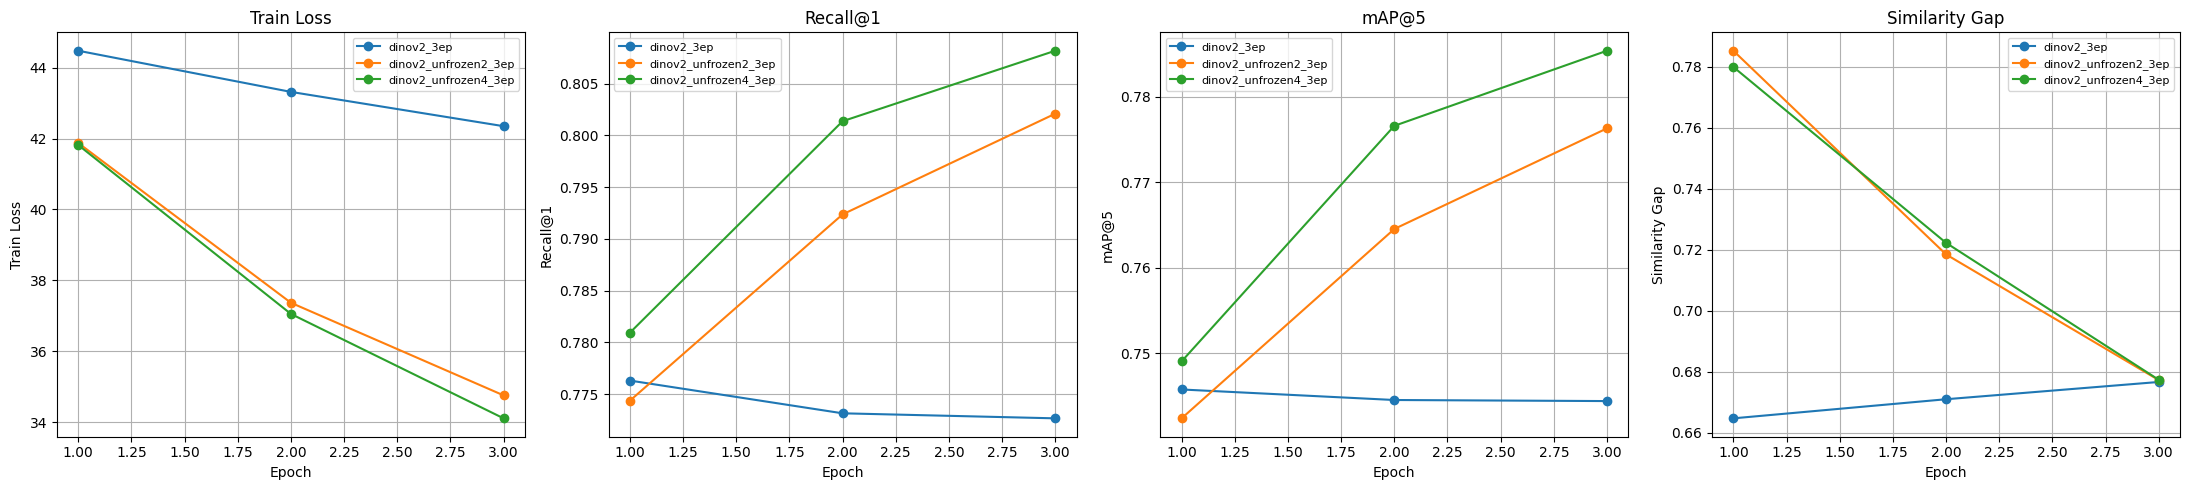

In [31]:
# Графики Train Loss, Recall@1, mAP@5 и SimGap по трём конфигурациям DINOv2
df = load_results()
pool_names = [f'dinov2_{EXP_EPOCHS}ep',f'dinov2_unfrozen2_{EXP_EPOCHS}ep',f'dinov2_unfrozen4_{EXP_EPOCHS}ep']  # список имён экспериментов
table = df[df['experiment_name'].isin(pool_names)].copy()

if table.empty:
    print("Нет данных по указанным экспериментам. Проверьте experiment_results.csv.")
else:
    fig, axes = plt.subplots(1, 4, figsize=(22, 5))
    metrics = ['train_loss', 'val_recall@1', 'val_map@5', 'val_simgap']
    titles = ['Train Loss', 'Recall@1', 'mAP@5', 'Similarity Gap']
    colors = ['tab:blue', 'tab:orange', 'tab:green']
    
    for ax, metric, title in zip(axes, metrics, titles):
        for exp_name, color in zip(pool_names, colors):
            exp_data = table[table['experiment_name'] == exp_name]
            if not exp_data.empty:
                ax.plot(exp_data['epoch'], exp_data[metric], 
                        marker='o', label=exp_name, color=color)
        ax.set_xlabel('Epoch')
        ax.set_ylabel(title)
        ax.set_title(title)
        ax.legend(fontsize=8)
        ax.grid(True)
    
    plt.tight_layout()
    plt.show()

### Четыре размороженных блока DINOv2 выглядят перспективней двух.

In [33]:
EXP_EPOCHS = 3
exp_name = f'swin_frozen01_{EXP_EPOCHS}ep'

old_df = load_results()
done = set(old_df['experiment_name'].tolist()) if not old_df.empty else set()

if exp_name in done:
    print(f"'{exp_name}' уже существует, пропускаем.")
else:

    model = SwinWithProjectorPartial(freeze_stages=[0,1]).to(Config.DEVICE)
        
    dummy = torch.randn(2, 3, Config.IMG_SIZE, Config.IMG_SIZE).to(Config.DEVICE)
    with torch.no_grad():
        emb_dim = model(dummy).shape[1]

    loss_func = losses.ArcFaceLoss(
        num_classes=num_classes,
        embedding_size=emb_dim,
        margin=Config.ARC_MARGIN,
        scale=Config.ARC_SCALE
    ).to(Config.DEVICE)

    unfrozen_backbone_params = [p for p in model.backbone.parameters() if p.requires_grad]
    optimizer = torch.optim.AdamW([
        {'params': unfrozen_backbone_params, 'lr': Config.LR * 0.1, 'weight_decay': Config.WEIGHT_DECAY},
        {'params': model.proj.parameters(),  'lr': Config.LR,    'weight_decay': Config.WEIGHT_DECAY},
        {'params': loss_func.parameters(),   'lr': Config.LR,    'weight_decay': 0.0}])


    trainer = Trainer(model, loss_func, optimizer, experiment_name=exp_name)
    trainer.train(train_loader, val_loader, EXP_EPOCHS)

    del model, loss_func, optimizer, trainer
    gc.collect()
    torch.cuda.empty_cache()

Epoch 1/3: 100%|██████████| 607/607 [05:22<00:00,  1.88it/s, loss=41.2]
Epoch 1 | Train Loss: 41.6615
Epoch 1 | mAP@5: 0.7317 | Val Recall@1: 0.7722 | SimGap: 0.6734
Epoch 2/3: 100%|██████████| 607/607 [05:22<00:00,  1.88it/s, loss=38.1]
Epoch 2 | Train Loss: 39.7530
Epoch 2 | mAP@5: 0.7554 | Val Recall@1: 0.7892 | SimGap: 0.7003
Epoch 3/3: 100%|██████████| 607/607 [05:22<00:00,  1.88it/s, loss=38.1]
Epoch 3 | Train Loss: 38.3415
Epoch 3 | mAP@5: 0.7737 | Val Recall@1: 0.8023 | SimGap: 0.6962


### Swin стабильно растет в качестве, но обучается трижды медленнее DINOv2 — 6 минут на эпоху.

In [34]:
EXP_EPOCHS = 3
exp_name = f'swin_frozen012_{EXP_EPOCHS}ep'

old_df = load_results()
done = set(old_df['experiment_name'].tolist()) if not old_df.empty else set()

if exp_name in done:
    print(f"'{exp_name}' уже существует, пропускаем.")
else:

    model = SwinWithProjectorPartial(freeze_stages=[0,1,2]).to(Config.DEVICE)
        
    dummy = torch.randn(2, 3, Config.IMG_SIZE, Config.IMG_SIZE).to(Config.DEVICE)
    with torch.no_grad():
        emb_dim = model(dummy).shape[1]

    loss_func = losses.ArcFaceLoss(
        num_classes=num_classes,
        embedding_size=emb_dim,
        margin=Config.ARC_MARGIN,
        scale=Config.ARC_SCALE
    ).to(Config.DEVICE)
    
    unfrozen_backbone_params = [p for p in model.backbone.parameters() if p.requires_grad]
    optimizer = torch.optim.AdamW([
        {'params': unfrozen_backbone_params, 'lr': Config.LR * 0.1, 'weight_decay': Config.WEIGHT_DECAY},
        {'params': model.proj.parameters(),  'lr': Config.LR,    'weight_decay': Config.WEIGHT_DECAY},
        {'params': loss_func.parameters(),   'lr': Config.LR,    'weight_decay': 0.0}])
    
    trainer = Trainer(model, loss_func, optimizer, experiment_name=exp_name)
    trainer.train(train_loader, val_loader, EXP_EPOCHS)        # обучение на 3 эпохах (по Config.EPOCHS)

    del model, loss_func, optimizer, trainer
    gc.collect()
    torch.cuda.empty_cache()

Epoch 1/3: 100%|██████████| 607/607 [02:58<00:00,  3.40it/s, loss=42.3]
Epoch 1 | Train Loss: 41.7650
Epoch 1 | mAP@5: 0.7173 | Val Recall@1: 0.7552 | SimGap: 0.6375
Epoch 2/3: 100%|██████████| 607/607 [02:58<00:00,  3.40it/s, loss=40.1]
Epoch 2 | Train Loss: 40.0063
Epoch 2 | mAP@5: 0.7213 | Val Recall@1: 0.7581 | SimGap: 0.6552
Epoch 3/3: 100%|██████████| 607/607 [02:58<00:00,  3.41it/s, loss=38.8]
Epoch 3 | Train Loss: 38.7183
Epoch 3 | mAP@5: 0.7326 | Val Recall@1: 0.7678 | SimGap: 0.6598


In [35]:
df = load_results()
target_exps = ['swin_frozen012_3ep','swin_frozen01_3ep','swin_1ep']
table = df[df['experiment_name'].isin(target_exps)].copy()
table = table.round({'train_loss': 4, 'val_recall@1': 4, 'val_map@5': 4, 'val_simgap': 4, 'training_time_sec': 1})

# Выводим нужные колонки с сортировкой по эпохам и имени эксперимента
cols = ['experiment_name', 'epoch', 'train_loss', 'val_recall@1', 'val_map@5', 'val_simgap', 'training_time_sec']
print(table[cols].sort_values(['epoch', 'experiment_name']).to_string(index=False))

   experiment_name  epoch  train_loss  val_recall@1  val_map@5  val_simgap  training_time_sec
          swin_1ep      1     41.7101        0.7664     0.7294      0.6567              495.6
swin_frozen012_3ep      1     41.7650        0.7552     0.7173      0.6375              265.0
 swin_frozen01_3ep      1     41.6615        0.7722     0.7317      0.6734              409.2
swin_frozen012_3ep      2     40.0063        0.7581     0.7213      0.6552              529.9
 swin_frozen01_3ep      2     39.7530        0.7892     0.7554      0.7003              818.3
swin_frozen012_3ep      3     38.7183        0.7678     0.7326      0.6598              794.7
 swin_frozen01_3ep      3     38.3415        0.8023     0.7737      0.6962             1227.2


### Заморозка трех стадий Swin сократила время эпохи до 3 минут, но заметно снизила метрики ранжирования. 
### Потери в качестве подтверждают, что модели Swin критически важна разморозка глубоких слоев.

### Итоговое заключение: **DINOv2 с разморозкой четырех последних блоков** обеспечивает наилучшую точность ранжирования при минимальном времени обучения на эпоху.
---

In [24]:
Config.BATCH_SIZE = 128  # Батч 128 помещается в памяти при обучении DINOv2
Config.GRAD_ACCUM = 1

train_strong_dataset = ShopeeDataset(train_df, train_strong_transforms)
train_strong_loader = DataLoader(
    train_strong_dataset, 
    batch_size=Config.BATCH_SIZE, 
    shuffle=True, 
    num_workers=Config.NUM_WORKERS,
    pin_memory=True,
    persistent_workers=(Config.NUM_WORKERS > 0)
)
val_loader = DataLoader(
    val_dataset, 
    batch_size=Config.BATCH_SIZE, 
    shuffle=False, 
    num_workers=Config.NUM_WORKERS,
    pin_memory=True,
    persistent_workers=(Config.NUM_WORKERS > 0)
)

## Функция потерь и сильные аугментации

In [34]:
EXP_EPOCHS = 5

experiments = [
    (f'dinov2_unfrozen4_SubCenterk3_{EXP_EPOCHS}ep',  3),
    (f'dinov2_unfrozen4_SubCenterk2_{EXP_EPOCHS}ep',  2),
    (f'dinov2_unfrozen4_ArcFace_{EXP_EPOCHS}ep',  1)]

old_df = load_results()
done = set(old_df['experiment_name'].tolist()) if not old_df.empty else set()

for exp_name, sub_centers_k in experiments:
    if exp_name in done:
        print(f"'{exp_name}' уже существует, пропускаем.")
        continue

    print(f"\n{'='*60}")
    print(f"Старт: {exp_name} | sub_centers_k={sub_centers_k}")
    
    model = DinoWithProjectorUnfrozen(unfreeze_blocks=4).to(Config.DEVICE)

    if sub_centers_k ==1:
       loss_func = losses.ArcFaceLoss(
            num_classes=num_classes,
            embedding_size=384,
            margin=Config.ARC_MARGIN,
            scale=Config.ARC_SCALE
        ).to(Config.DEVICE)
    else:
        loss_func = SubCenterArcFaceLoss(    
            num_classes=num_classes,
            embedding_size=384,
            margin=Config.ARC_MARGIN,
            scale=Config.ARC_SCALE,
            sub_centers=sub_centers_k          # число подцентров
        ).to(Config.DEVICE)

    unfrozen_backbone_params = [p for p in model.backbone.parameters() if p.requires_grad]
    optimizer = torch.optim.AdamW([
        {'params': unfrozen_backbone_params, 'lr': 1e-5,       'weight_decay': Config.WEIGHT_DECAY},
        {'params': model.proj.parameters(),  'lr': 1e-3,       'weight_decay': Config.WEIGHT_DECAY},
        {'params': loss_func.parameters(),   'lr': 1e-3,       'weight_decay': 0.0}])

    trainer = Trainer(model, loss_func, optimizer, experiment_name=exp_name)
    trainer.train(train_strong_loader, val_loader, EXP_EPOCHS)    # Используем dataloader c сильными аугментациями

    del model, loss_func, optimizer, trainer
    gc.collect()
    torch.cuda.empty_cache()


Старт: dinov2_unfrozen4_SubCenterk3_5ep | sub_centers_k=3


Epoch 1/5: 100%|██████████| 152/152 [02:00<00:00,  1.26it/s, loss=39.4]
Epoch 1 | Train Loss: 40.9138
Epoch 1 | mAP@5: 0.7517 | Val Recall@1: 0.7822 | SimGap: 0.7864
Epoch 2/5: 100%|██████████| 152/152 [02:02<00:00,  1.24it/s, loss=35.6]
Epoch 2 | Train Loss: 36.2819
Epoch 2 | mAP@5: 0.7705 | Val Recall@1: 0.7982 | SimGap: 0.7306
Epoch 3/5: 100%|██████████| 152/152 [01:58<00:00,  1.29it/s, loss=31.8]
Epoch 3 | Train Loss: 33.4338
Epoch 3 | mAP@5: 0.7783 | Val Recall@1: 0.8009 | SimGap: 0.6928
Epoch 4/5: 100%|██████████| 152/152 [01:56<00:00,  1.31it/s, loss=30.5]
Epoch 4 | Train Loss: 31.1628
Epoch 4 | mAP@5: 0.7874 | Val Recall@1: 0.8077 | SimGap: 0.6542
Epoch 5/5: 100%|██████████| 152/152 [02:00<00:00,  1.26it/s, loss=27.6]
Epoch 5 | Train Loss: 29.1797
Epoch 5 | mAP@5: 0.7913 | Val Recall@1: 0.8099 | SimGap: 0.6286

Старт: dinov2_unfrozen4_SubCenterk2_5ep | sub_centers_k=2
Epoch 1/5: 100%|██████████| 152/152 [02:01<00:00,  1.26it/s, loss=38.7]
Epoch 1 | Train Loss: 41.1781
Epoch 1 |

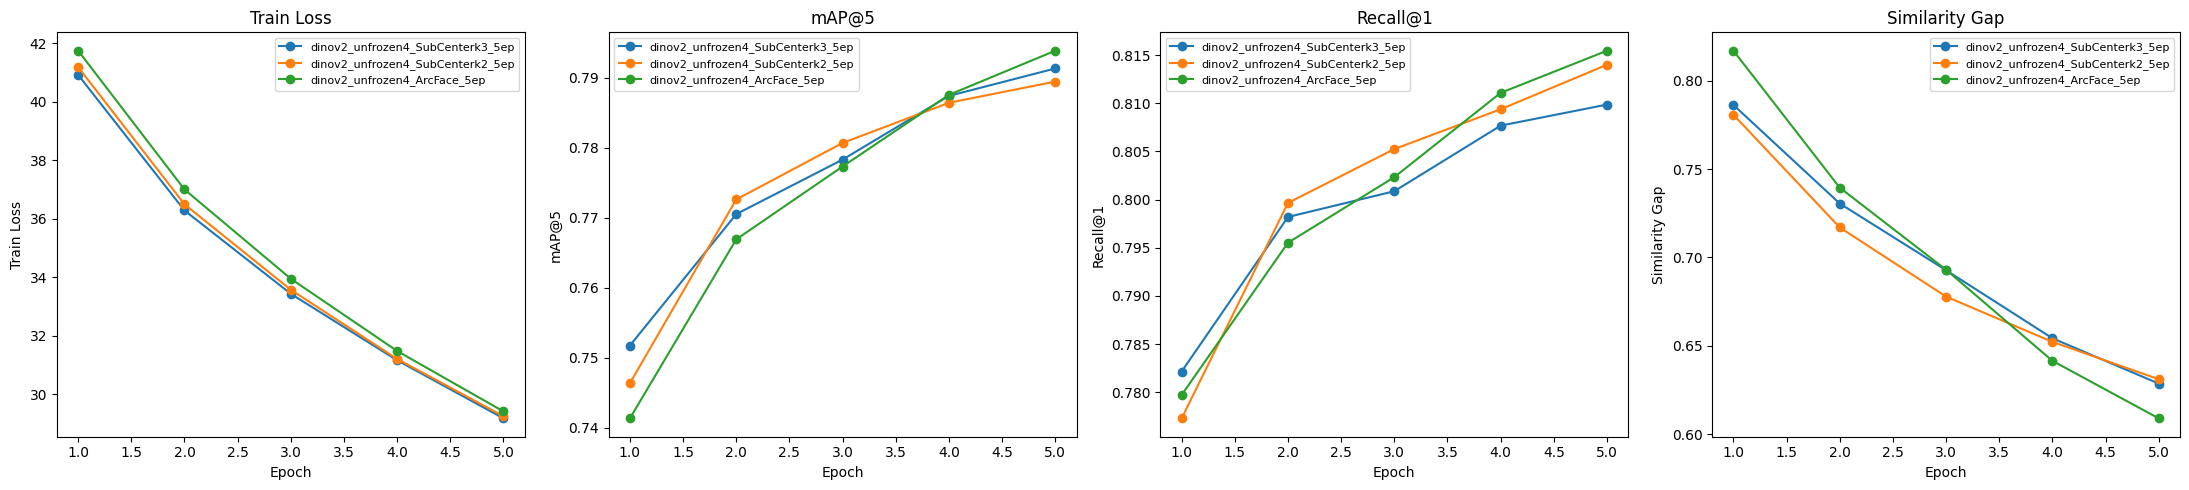

In [35]:
# Графики сравнения ArcFace и SubCenter ArcFace
df = load_results()
pool_names = [e[0] for e in experiments]
table = df[df['experiment_name'].isin(pool_names)].copy()

if table.empty:
    print("Нет данных по указанным экспериментам. Проверьте experiment_results.csv.")
else:
    fig, axes = plt.subplots(1, 4, figsize=(22, 5))
    metrics = ['train_loss','val_map@5', 'val_recall@1',  'val_simgap']
    titles = ['Train Loss', 'mAP@5', 'Recall@1',  'Similarity Gap']
    
    for ax, metric, title in zip(axes, metrics, titles):
        for exp_name in pool_names:
            exp_data = table[table['experiment_name'] == exp_name]
            if not exp_data.empty:
                line, = ax.plot(exp_data['epoch'], exp_data[metric], 
                                marker='o', label=exp_name)
        ax.set_xlabel('Epoch')
        ax.set_ylabel(title)
        ax.set_title(title)
        ax.legend(fontsize=8)

    plt.tight_layout()
    plt.show()

### ArcFace обогнал SubCenter по Recall, mAP и показал лучшую динамику обучения.

### Scale и Margin

In [26]:
EXP_EPOCHS = 3
exp_name = f'dinov2_unfrozen4_ArcFace_s32_{EXP_EPOCHS}ep'

old_df = load_results()
done = set(old_df['experiment_name'].tolist()) if not old_df.empty else set()

if exp_name in done:
    print(f"'{exp_name}' уже существует, пропускаем.")
else:

    model = DinoWithProjectorUnfrozen(unfreeze_blocks=4).to(Config.DEVICE)

    loss_func = losses.ArcFaceLoss(
        num_classes=num_classes,
        embedding_size=384,
        margin=Config.ARC_MARGIN,
        scale=32
    ).to(Config.DEVICE)

    unfrozen_backbone_params = [p for p in model.backbone.parameters() if p.requires_grad]
    optimizer = torch.optim.AdamW([
        {'params': unfrozen_backbone_params, 'lr': 1e-5, 'weight_decay': Config.WEIGHT_DECAY},
        {'params': model.proj.parameters(),  'lr': 1e-3,       'weight_decay': Config.WEIGHT_DECAY}, 
        {'params': loss_func.parameters(),   'lr': 1e-3,       'weight_decay': 0.0}])
    
    trainer = Trainer(model, loss_func, optimizer, experiment_name=exp_name)
    trainer.train(train_strong_loader, val_loader, EXP_EPOCHS)      
    
    del model, loss_func, optimizer, trainer
    gc.collect()
    torch.cuda.empty_cache()

Epoch 1/3: 100%|██████████| 152/152 [01:59<00:00,  1.28it/s, loss=23.5]
Epoch 1 | Train Loss: 24.2521
Epoch 1 | mAP@5: 0.7660 | Val Recall@1: 0.7902 | SimGap: 0.7371
Epoch 2/3: 100%|██████████| 152/152 [01:51<00:00,  1.36it/s, loss=21.4]
Epoch 2 | Train Loss: 21.5439
Epoch 2 | mAP@5: 0.7879 | Val Recall@1: 0.8074 | SimGap: 0.6786
Epoch 3/3: 100%|██████████| 152/152 [01:53<00:00,  1.34it/s, loss=19.3]
Epoch 3 | Train Loss: 19.8413
Epoch 3 | mAP@5: 0.7936 | Val Recall@1: 0.8121 | SimGap: 0.6458


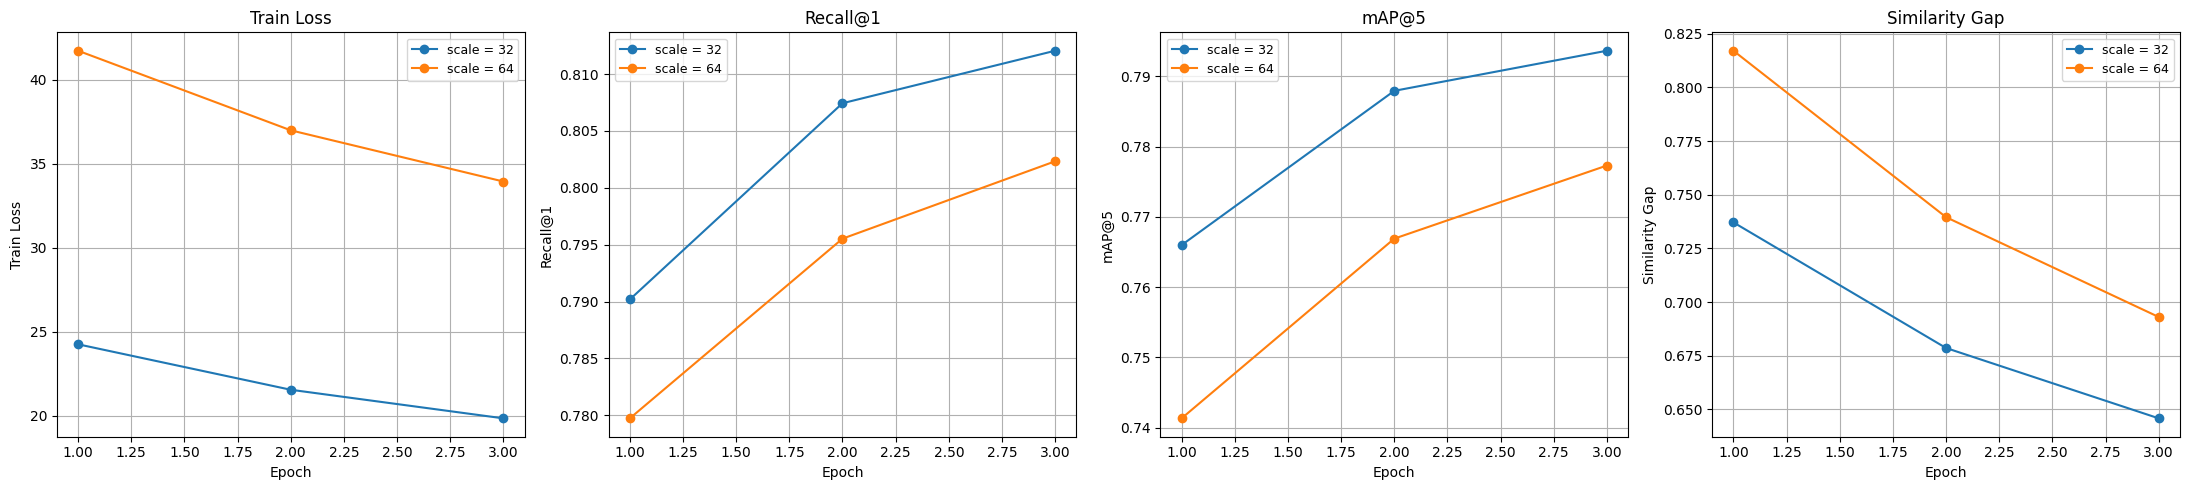

In [27]:
# Сравнение двух экспериментов DINOv2 с разным scale
exp1 = 'dinov2_unfrozen4_ArcFace_s32_3ep'   # scale = 32
exp2 = 'dinov2_unfrozen4_ArcFace_5ep'       # scale = 64

df = load_results()
plot_df = df[df['experiment_name'].isin([exp1, exp2])].copy()

if plot_df.empty:
    print("Нет данных по указанным экспериментам.")
else:
    plot_df = plot_df[plot_df['epoch'] <= 3]
    fig, axes = plt.subplots(1, 4, figsize=(22, 5))
    metrics = ['train_loss', 'val_recall@1', 'val_map@5', 'val_simgap']
    titles  = ['Train Loss', 'Recall@1', 'mAP@5', 'Similarity Gap']
    labels = {
        exp1: 'scale = 32',
        exp2: 'scale = 64'
    }
    
    for ax, metric, title in zip(axes, metrics, titles):
        lines = []
        for exp_name in [exp1, exp2]:
            exp_data = plot_df[plot_df['experiment_name'] == exp_name]
            if not exp_data.empty:
                line, = ax.plot(exp_data['epoch'], exp_data[metric], 
                                marker='o', label=labels[exp_name])
                lines.append(line)
        ax.set_xlabel('Epoch')
        ax.set_ylabel(title)
        ax.set_title(title)
        if lines:
            ax.legend(fontsize=9)
        ax.grid(True)
    
    plt.tight_layout()
    plt.show()

### Scale 32 дал значительный прирост метрик относительно 64.

In [29]:
EXP_EPOCHS = 5

experiments = [
    (f'dinov2_unfrozen4_ArcFace_m17_{EXP_EPOCHS}ep',  17),
    (f'dinov2_unfrozen4_ArcFace_m20_{EXP_EPOCHS}ep',  20),
    (f'dinov2_unfrozen4_ArcFace_m23_{EXP_EPOCHS}ep',  23),
    (f'dinov2_unfrozen4_ArcFace_m26_{EXP_EPOCHS}ep',  26),
    (f'dinov2_unfrozen4_ArcFace_m29_{EXP_EPOCHS}ep',  29),
    (f'dinov2_unfrozen4_ArcFace_m32_{EXP_EPOCHS}ep',  32)]

old_df = load_results()
done = set(old_df['experiment_name'].tolist()) if not old_df.empty else set()

for exp_name, margin in experiments:
    if exp_name in done:
        print(f"'{exp_name}' уже существует, пропускаем.")
        continue

    print(f"\n{'='*60}")
    print(f"Старт: {exp_name} | margin={margin}")
    
    model = DinoWithProjectorUnfrozen(unfreeze_blocks=4).to(Config.DEVICE)

    loss_func = losses.ArcFaceLoss(
        num_classes=num_classes,
        embedding_size=384,
        margin=margin,
        scale=32
    ).to(Config.DEVICE)

    unfrozen_backbone_params = [p for p in model.backbone.parameters() if p.requires_grad]
    optimizer = torch.optim.AdamW([
        {'params': unfrozen_backbone_params, 'lr': 1e-5,       'weight_decay': Config.WEIGHT_DECAY},
        {'params': model.proj.parameters(),  'lr': 1e-3,       'weight_decay': Config.WEIGHT_DECAY},
        {'params': loss_func.parameters(),   'lr': 1e-3,       'weight_decay': 0.0}])

    trainer = Trainer(model, loss_func, optimizer, experiment_name=exp_name)
    trainer.train(train_strong_loader, val_loader, EXP_EPOCHS)    # Используем dataloader c сильными аугментациями

    del model, loss_func, optimizer, trainer
    gc.collect()
    torch.cuda.empty_cache()


Старт: dinov2_unfrozen4_ArcFace_m17_5ep | margin=17
Epoch 1/5: 100%|██████████| 152/152 [01:54<00:00,  1.33it/s, loss=16.3]
Epoch 1 | Train Loss: 18.2143
Epoch 1 | mAP@5: 0.7763 | Val Recall@1: 0.7994 | SimGap: 0.7282
Epoch 2/5: 100%|██████████| 152/152 [01:55<00:00,  1.32it/s, loss=15.1]
Epoch 2 | Train Loss: 15.3286
Epoch 2 | mAP@5: 0.7891 | Val Recall@1: 0.8111 | SimGap: 0.6687
Epoch 3/5: 100%|██████████| 152/152 [01:57<00:00,  1.30it/s, loss=13.9]
Epoch 3 | Train Loss: 13.6407
Epoch 3 | mAP@5: 0.7971 | Val Recall@1: 0.8177 | SimGap: 0.6433
Epoch 4/5: 100%|██████████| 152/152 [01:56<00:00,  1.30it/s, loss=12.8]
Epoch 4 | Train Loss: 12.3635
Epoch 4 | mAP@5: 0.7996 | Val Recall@1: 0.8189 | SimGap: 0.6153
Epoch 5/5: 100%|██████████| 152/152 [01:55<00:00,  1.32it/s, loss=12.3]
Epoch 5 | Train Loss: 11.2984
Epoch 5 | mAP@5: 0.8008 | Val Recall@1: 0.8213 | SimGap: 0.5965

Старт: dinov2_unfrozen4_ArcFace_m20_5ep | margin=20
Epoch 1/5: 100%|██████████| 152/152 [01:53<00:00,  1.34it/s, los

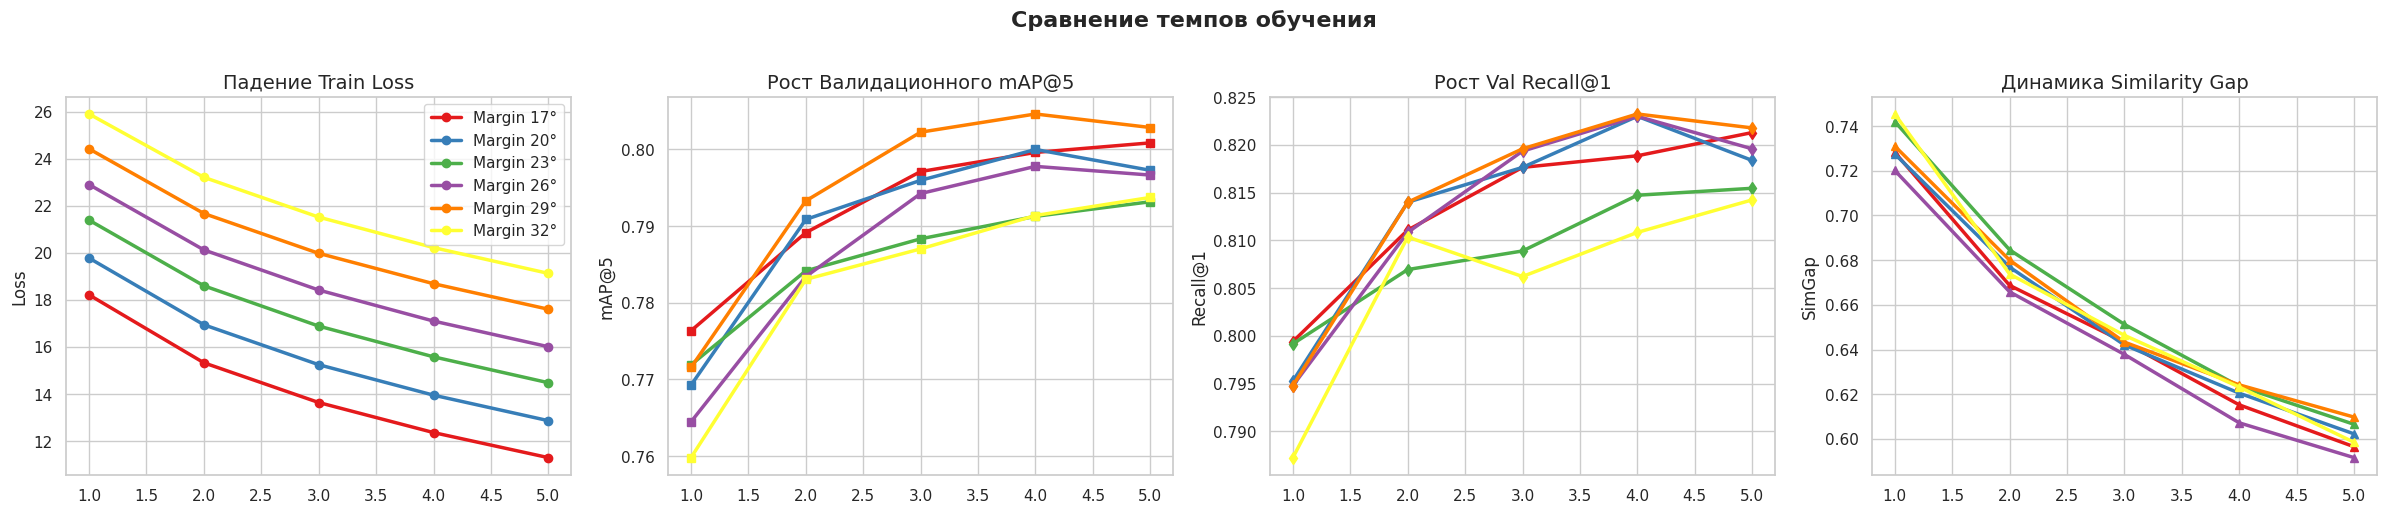

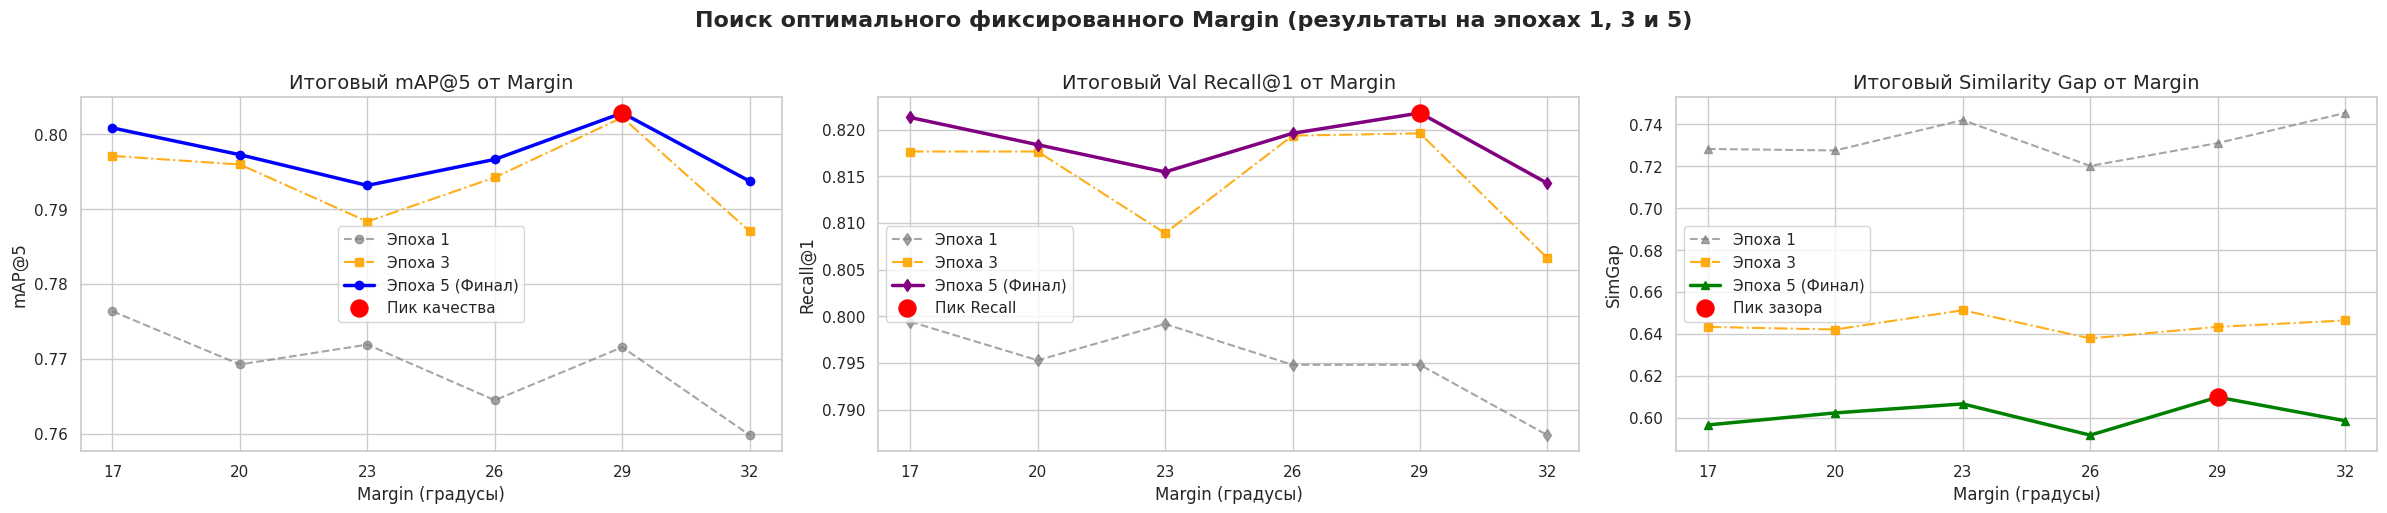


Таблица приростов метрик по интервалам эпох (1→3, 3→5, 1→5):
 margin  Δ mAP 1→3  Δ mAP 3→5  Δ mAP 1→5  Δ Recall 1→3  Δ Recall 3→5  Δ Recall 1→5  Δ Gap 1→3  Δ Gap 3→5  Δ Gap 1→5
     17     0.0208     0.0037     0.0245        0.0182        0.0036        0.0219    -0.0850    -0.0468    -0.1317
     20     0.0267     0.0013     0.0280        0.0224        0.0007        0.0231    -0.0855    -0.0398    -0.1253
     23     0.0164     0.0048     0.0213        0.0097        0.0066        0.0163    -0.0908    -0.0447    -0.1355
     26     0.0298     0.0024     0.0322        0.0246        0.0002        0.0248    -0.0823    -0.0462    -0.1285
     29     0.0307     0.0006     0.0313        0.0248        0.0022        0.0270    -0.0877    -0.0336    -0.1213
     32     0.0272     0.0067     0.0339        0.0190        0.0080        0.0270    -0.0991    -0.0479    -0.1469


In [30]:
df_all = load_results()   
margins = [m for _, m in experiments]   
experiment_names = [name for name, _ in experiments]

# Фильтруем только нужные эксперименты
df_exp = df_all[df_all['experiment_name'].isin(experiment_names)].copy()
df_plot = df_exp.copy()   

if df_plot.empty:
    print("Нет данных для построения графиков.")
else:
    margin_map = {name: m for name, m in experiments}
    df_plot['margin'] = df_plot['experiment_name'].map(margin_map)

    # Стиль
    sns.set_theme(style="whitegrid")
    plt.rcParams.update({'font.size': 11, 'axes.labelsize': 12, 'axes.titlesize': 14})

    # ГРАФИК 1: Динамика метрик по эпохам для каждого margin
    fig, axes = plt.subplots(1, 4, figsize=(24, 5))
    colors = sns.color_palette("Set1", len(margins))

    for idx, m in enumerate(margins):
        sub = df_plot[df_plot['margin'] == m].sort_values('epoch')
        if sub.empty:
            continue
        label = f"Margin {m}°"
        axes[0].plot(sub['epoch'], sub['train_loss'], marker='o', linewidth=2.5, color=colors[idx], label=label)
        axes[1].plot(sub['epoch'], sub['val_map@5'], marker='s', linewidth=2.5, color=colors[idx])
        axes[2].plot(sub['epoch'], sub['val_recall@1'], marker='d', linewidth=2.5, color=colors[idx])
        axes[3].plot(sub['epoch'], sub['val_simgap'], marker='^', linewidth=2.5, color=colors[idx])

    axes[0].set_title("Падение Train Loss")
    axes[0].set_ylabel("Loss")
    axes[0].legend(loc="upper right")
    axes[1].set_title("Рост Валидационного mAP@5")
    axes[1].set_ylabel("mAP@5")
    axes[2].set_title("Рост Val Recall@1")
    axes[2].set_ylabel("Recall@1")
    axes[3].set_title("Динамика Similarity Gap")
    axes[3].set_ylabel("SimGap")

    plt.suptitle("Сравнение темпов обучения", y=1.02, fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.show()

    # ГРАФИК 2: Зависимость метрик от margin на эпохах 1, 3, 5
    ep1 = df_plot[df_plot['epoch'] == 1].sort_values('margin')
    ep3 = df_plot[df_plot['epoch'] == 3].sort_values('margin')
    ep5 = df_plot[df_plot['epoch'] == 5].sort_values('margin')

    fig, axes = plt.subplots(1, 3, figsize=(24, 5))

    # mAP@5
    axes[0].plot(ep1['margin'], ep1['val_map@5'], marker='o', linestyle='--', color='gray', alpha=0.7, label='Эпоха 1')
    axes[0].plot(ep3['margin'], ep3['val_map@5'], marker='s', linestyle='-.', color='orange', alpha=0.9, label='Эпоха 3')
    axes[0].plot(ep5['margin'], ep5['val_map@5'], marker='o', linestyle='-', color='blue', linewidth=2.5, label='Эпоха 5 (Финал)')
    best_map_idx = ep5['val_map@5'].idxmax() if not ep5.empty else None
    if best_map_idx is not None:
        axes[0].scatter(ep5['margin'][best_map_idx], ep5['val_map@5'][best_map_idx], color='red', s=150, zorder=5, label='Пик качества')
    axes[0].set_title("Итоговый mAP@5 от Margin")
    axes[0].set_xlabel("Margin (градусы)")
    axes[0].set_ylabel("mAP@5")
    axes[0].set_xticks(margins)
    axes[0].legend()

    # Recall@1
    axes[1].plot(ep1['margin'], ep1['val_recall@1'], marker='d', linestyle='--', color='gray', alpha=0.7, label='Эпоха 1')
    axes[1].plot(ep3['margin'], ep3['val_recall@1'], marker='s', linestyle='-.', color='orange', alpha=0.9, label='Эпоха 3')
    axes[1].plot(ep5['margin'], ep5['val_recall@1'], marker='d', linestyle='-', color='purple', linewidth=2.5, label='Эпоха 5 (Финал)')
    best_recall_idx = ep5['val_recall@1'].idxmax() if not ep5.empty else None
    if best_recall_idx is not None:
        axes[1].scatter(ep5['margin'][best_recall_idx], ep5['val_recall@1'][best_recall_idx], color='red', s=150, zorder=5, label='Пик Recall')
    axes[1].set_title("Итоговый Val Recall@1 от Margin")
    axes[1].set_xlabel("Margin (градусы)")
    axes[1].set_ylabel("Recall@1")
    axes[1].set_xticks(margins)
    axes[1].legend()

    # SimGap
    axes[2].plot(ep1['margin'], ep1['val_simgap'], marker='^', linestyle='--', color='gray', alpha=0.7, label='Эпоха 1')
    axes[2].plot(ep3['margin'], ep3['val_simgap'], marker='s', linestyle='-.', color='orange', alpha=0.9, label='Эпоха 3')
    axes[2].plot(ep5['margin'], ep5['val_simgap'], marker='^', linestyle='-', color='green', linewidth=2.5, label='Эпоха 5 (Финал)')
    best_gap_idx = ep5['val_simgap'].idxmax() if not ep5.empty else None
    if best_gap_idx is not None:
        axes[2].scatter(ep5['margin'][best_gap_idx], ep5['val_simgap'][best_gap_idx], color='red', s=150, zorder=5, label='Пик зазора')
    axes[2].set_title("Итоговый Similarity Gap от Margin")
    axes[2].set_xlabel("Margin (градусы)")
    axes[2].set_ylabel("SimGap")
    axes[2].set_xticks(margins)
    axes[2].legend()

    plt.suptitle("Поиск оптимального фиксированного Margin (результаты на эпохах 1, 3 и 5)", y=1.02, fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.show()

    # ТАБЛИЦА Приросты метрик (Δ1→3, Δ3→5, Δ1→5) 
    delta_data = []
    for m in margins:
        rows = df_plot[df_plot['margin'] == m]
        if len(rows) < 3:
            continue
        row_ep1 = rows[rows['epoch'] == 1].iloc[0]
        row_ep3 = rows[rows['epoch'] == 3].iloc[0]
        row_ep5 = rows[rows['epoch'] == 5].iloc[0]
        delta_data.append({
            'margin': m,
            'Δ mAP 1→3': round(row_ep3['val_map@5'] - row_ep1['val_map@5'], 4),
            'Δ mAP 3→5': round(row_ep5['val_map@5'] - row_ep3['val_map@5'], 4),
            'Δ mAP 1→5': round(row_ep5['val_map@5'] - row_ep1['val_map@5'], 4),
            'Δ Recall 1→3': round(row_ep3['val_recall@1'] - row_ep1['val_recall@1'], 4),
            'Δ Recall 3→5': round(row_ep5['val_recall@1'] - row_ep3['val_recall@1'], 4),
            'Δ Recall 1→5': round(row_ep5['val_recall@1'] - row_ep1['val_recall@1'], 4),
            'Δ Gap 1→3': round(row_ep3['val_simgap'] - row_ep1['val_simgap'], 4),
            'Δ Gap 3→5': round(row_ep5['val_simgap'] - row_ep3['val_simgap'], 4),
            'Δ Gap 1→5': round(row_ep5['val_simgap'] - row_ep1['val_simgap'], 4)
        })
    
    if delta_data:
        delta_df = pd.DataFrame(delta_data)
        print("\nТаблица приростов метрик по интервалам эпох (1→3, 3→5, 1→5):")
        print(delta_df.to_string(index=False))
    else:
        print("Недостаточно данных для построения приростов (нужны все три эпохи).")

### Margin 29 показывает наилучшие mAP и Recall, превосходя остальные.
---


In [25]:
Config.ARC_SCALE= 32
Config.ARC_MARGIN=29

## LR Finder

=== Поиск proj_lr (backbone полностью заморожен) ===


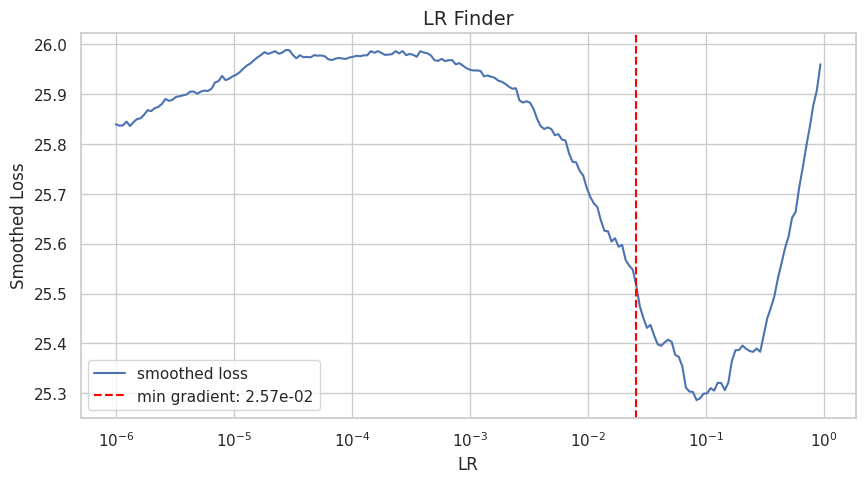

Max negative gradient at lr = 2.57e-02


In [38]:
# LR Finder для DINOv2 с unfreeze_blocks=4
model = DinoWithProjectorUnfrozen(unfreeze_blocks=4).to(Config.DEVICE)

loss_func = losses.ArcFaceLoss(
    num_classes=num_classes,
    embedding_size=384,
    margin=Config.ARC_MARGIN,
    scale = Config.ARC_SCALE,
).to(Config.DEVICE)

# Поиск proj_lr (backbone ПОЛНОСТЬЮ заморожен)
print("=== Поиск proj_lr (backbone полностью заморожен) ===")
for param in model.backbone.parameters():
    param.requires_grad = False

optimizer_stage1 = torch.optim.AdamW([
    {'params': model.proj.parameters(), 'lr': 1e-6},
    {'params': loss_func.parameters(),  'lr': 1e-6}])

df1 = lr_finder_fixed_groups(model, loss_func, train_loader, optimizer_stage1,vary_group_indices=[0, 1], start_lr=1e-6, end_lr=1, num_steps=200)

del optimizer_stage1
gc.collect()
torch.cuda.empty_cache()

In [26]:
proj_lr = 1e-2


=== Поиск backbone_lr для последних 4 блоков ===


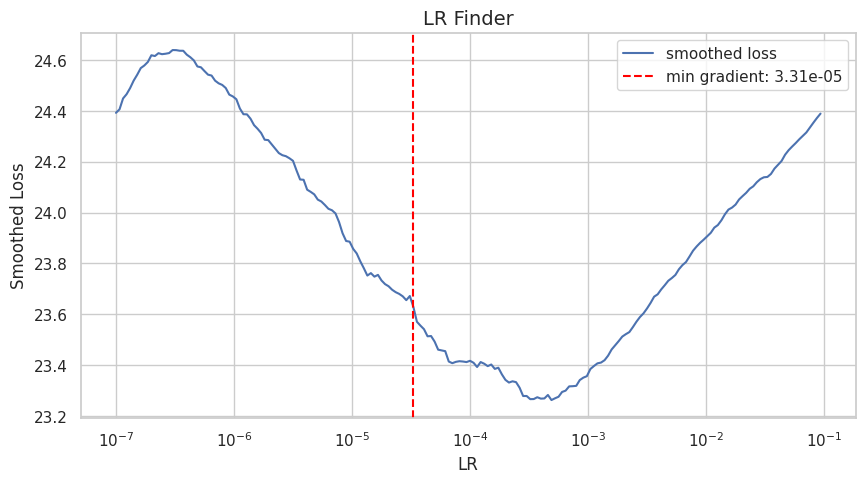

Max negative gradient at lr = 3.31e-05


In [41]:
# Поиск backbone_lr для последних 4 блоков 
print("\n=== Поиск backbone_lr для последних 4 блоков ===")
# Замораживаем всё, кроме последних 4 блоков
for param in model.backbone.parameters():
    param.requires_grad = False
for block in model.backbone.blocks[-4:]:
    for param in block.parameters():
        param.requires_grad = True

optimizer_stage2 = torch.optim.AdamW([
    {'params': model.backbone.parameters(), 'lr': 1e-7},   # обновятся только размороженные
    {'params': model.proj.parameters(),     'lr': proj_lr},
    {'params': loss_func.parameters(),      'lr': proj_lr}
])

df2 = lr_finder_fixed_groups(model, loss_func, train_loader, optimizer_stage2,vary_group_indices=[0],               # меняем lr только у размороженных блоков
                                               start_lr=1e-7, end_lr=1e-1, num_steps=200)

del optimizer_stage2
gc.collect()
torch.cuda.empty_cache()

In [27]:
back_lr = 2e-5

In [44]:
EXP_EPOCHS = 3
exp_name = f'dinov2_unfrozen4_optimizedLR_{EXP_EPOCHS}ep'

old_df = load_results()
done = set(old_df['experiment_name'].tolist()) if not old_df.empty else set()

if exp_name in done:
    print(f"'{exp_name}' уже существует, пропускаем.")
else:

    model = DinoWithProjectorUnfrozen(unfreeze_blocks=4).to(Config.DEVICE)
    
    loss_func = losses.ArcFaceLoss(
        num_classes=num_classes,
        embedding_size=384,
        margin=Config.ARC_MARGIN,
        scale = Config.ARC_SCALE,
    ).to(Config.DEVICE)

    unfrozen_backbone_params = [p for p in model.backbone.parameters() if p.requires_grad]
    optimizer = torch.optim.AdamW([
        {'params': unfrozen_backbone_params, 'lr': back_lr, 'weight_decay': Config.WEIGHT_DECAY},
        {'params': model.proj.parameters(),  'lr': proj_lr,       'weight_decay': Config.WEIGHT_DECAY}, 
        {'params': loss_func.parameters(),   'lr': proj_lr,       'weight_decay': 0.0}])
    
    trainer = Trainer(model, loss_func, optimizer, experiment_name=exp_name)
    trainer.train(train_strong_loader, val_loader, EXP_EPOCHS)      
    
    del model, loss_func, optimizer, trainer
    gc.collect()
    torch.cuda.empty_cache()

Epoch 1/3: 100%|██████████| 152/152 [01:56<00:00,  1.31it/s, loss=21]  
Epoch 1 | Train Loss: 22.9462
Epoch 1 | mAP@5: 0.7899 | Val Recall@1: 0.8135 | SimGap: 0.7323
Epoch 2/3: 100%|██████████| 152/152 [01:52<00:00,  1.35it/s, loss=18]  
Epoch 2 | Train Loss: 18.1411
Epoch 2 | mAP@5: 0.8140 | Val Recall@1: 0.8303 | SimGap: 0.6644
Epoch 3/3: 100%|██████████| 152/152 [01:53<00:00,  1.34it/s, loss=14]  
Epoch 3 | Train Loss: 14.6375
Epoch 3 | mAP@5: 0.8204 | Val Recall@1: 0.8335 | SimGap: 0.6480


## Weight decay

In [45]:
EXP_EPOCHS = 3

experiments = [
    (f'dinov2_unfrozen4_WD1e-3_{EXP_EPOCHS}ep',  1e-3),
    (f'dinov2_unfrozen4_WD1e-2_{EXP_EPOCHS}ep',  1e-2),
    (f'dinov2_unfrozen4_WD1e-1_{EXP_EPOCHS}ep',  1e-1)]

old_df = load_results()
done = set(old_df['experiment_name'].tolist()) if not old_df.empty else set()

for exp_name, weght_decay in experiments:
    if exp_name in done:
        print(f"'{exp_name}' уже существует, пропускаем.")
        continue

    print(f"\n{'='*60}")
    print(f"Старт: {exp_name} | weght_decay={weght_decay}")
    
    model = DinoWithProjectorUnfrozen(unfreeze_blocks=4).to(Config.DEVICE)
    
    loss_func = losses.ArcFaceLoss(
        num_classes=num_classes,
        embedding_size=384,
        margin=Config.ARC_MARGIN,
        scale = Config.ARC_SCALE,
    ).to(Config.DEVICE)
    
    unfrozen_backbone_params = [p for p in model.backbone.parameters() if p.requires_grad]
    optimizer = torch.optim.AdamW([
        {'params': unfrozen_backbone_params, 'lr': back_lr,    'weight_decay': weght_decay},
        {'params': model.proj.parameters(),  'lr': proj_lr,    'weight_decay': Config.WEIGHT_DECAY}, 
        {'params': loss_func.parameters(),   'lr': proj_lr,    'weight_decay': 0.0}])
    
    trainer = Trainer(model, loss_func, optimizer, experiment_name=exp_name)
    trainer.train(train_strong_loader, val_loader, EXP_EPOCHS)      
    
    del model, loss_func, optimizer, trainer
    gc.collect()
    torch.cuda.empty_cache()


Старт: dinov2_unfrozen4_WD1e-3_3ep | weght_decay=0.001
Epoch 1/3: 100%|██████████| 152/152 [01:53<00:00,  1.33it/s, loss=20.2]
Epoch 1 | Train Loss: 22.8665
Epoch 1 | mAP@5: 0.7975 | Val Recall@1: 0.8201 | SimGap: 0.7209
Epoch 2/3: 100%|██████████| 152/152 [01:58<00:00,  1.29it/s, loss=18.2]
Epoch 2 | Train Loss: 18.0042
Epoch 2 | mAP@5: 0.8171 | Val Recall@1: 0.8342 | SimGap: 0.6721
Epoch 3/3: 100%|██████████| 152/152 [01:54<00:00,  1.32it/s, loss=14.3]
Epoch 3 | Train Loss: 14.5070
Epoch 3 | mAP@5: 0.8166 | Val Recall@1: 0.8330 | SimGap: 0.6437

Старт: dinov2_unfrozen4_WD1e-2_3ep | weght_decay=0.01
Epoch 1/3: 100%|██████████| 152/152 [01:58<00:00,  1.29it/s, loss=20.3]
Epoch 1 | Train Loss: 22.9203
Epoch 1 | mAP@5: 0.7999 | Val Recall@1: 0.8232 | SimGap: 0.7336
Epoch 2/3: 100%|██████████| 152/152 [01:56<00:00,  1.31it/s, loss=17.6]
Epoch 2 | Train Loss: 18.0488
Epoch 2 | mAP@5: 0.8165 | Val Recall@1: 0.8359 | SimGap: 0.6714
Epoch 3/3: 100%|██████████| 152/152 [01:55<00:00,  1.32it/s

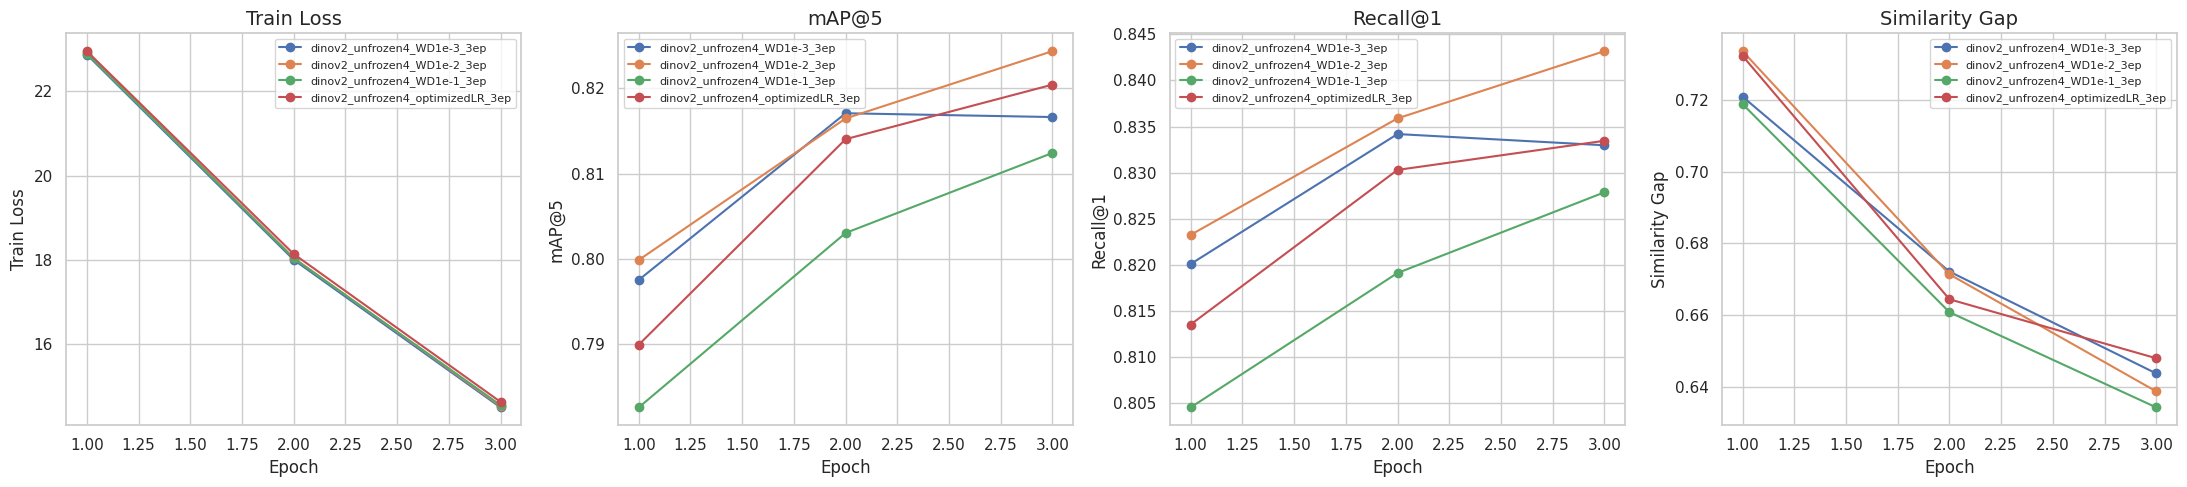

In [46]:
# Графики сравнения ArcFace и SubCenter ArcFace
df = load_results()
pool_names = [e[0] for e in experiments] + [f'dinov2_unfrozen4_optimizedLR_{EXP_EPOCHS}ep']
table = df[df['experiment_name'].isin(pool_names)].copy()

if table.empty:
    print("Нет данных по указанным экспериментам. Проверьте experiment_results.csv.")
else:
    fig, axes = plt.subplots(1, 4, figsize=(22, 5))
    metrics = ['train_loss','val_map@5', 'val_recall@1',  'val_simgap']
    titles = ['Train Loss', 'mAP@5', 'Recall@1',  'Similarity Gap']
    
    for ax, metric, title in zip(axes, metrics, titles):
        for exp_name in pool_names:
            exp_data = table[table['experiment_name'] == exp_name]
            if not exp_data.empty:
                line, = ax.plot(exp_data['epoch'], exp_data[metric], 
                                marker='o', label=exp_name)
        ax.set_xlabel('Epoch')
        ax.set_ylabel(title)
        ax.set_title(title)
        ax.legend(fontsize=8)

    plt.tight_layout()
    plt.show()

## Weight decay 0.01 для backbone дал наивысшие mAP, Recall

In [28]:
back_weight_decay= 1e-2

---
## Ансамбль с Swin

In [35]:
class CombinedModel(nn.Module):
    """
    Ансамбль Swin + DINOv2:
      - Swin с выборочной заморозкой стадий (patch_embed всегда frozen)
      - DINOv2 с разморозкой последних unfreeze_blocks
    Признаки конкатенируются и подаются в общий обучаемый проектор.
    """
    def __init__(self,
                 swin_name='swin_small_patch4_window7_224',
                 dinov2_name='vit_small_patch14_dinov2.lvd142m',
                 img_size=336, out_dim=512,
                 freeze_stages=None,       # список индексов стадий Swin для заморозки (0..3)
                 unfreeze_blocks=2):       # число размораживаемых последних блоков DINOv2
        super().__init__()

        #Swin
        self.swin = timm.create_model(swin_name, pretrained=True, num_classes=0, img_size=img_size, dynamic_img_pad=True)
        swin_dim = self.swin.num_features
        # patch_embed всегда frozen
        for p in self.swin.patch_embed.parameters():
            p.requires_grad = False
        # заморозка указанных стадий
        if freeze_stages is not None:
            for stage_idx in freeze_stages:
                for p in self.swin.layers[stage_idx].parameters():
                    p.requires_grad = False

        # DINOv2
        self.dino = timm.create_model(dinov2_name, pretrained=True, num_classes=0, img_size=img_size)
        dino_dim = 384 
        for p in self.dino.parameters():
            p.requires_grad = False
        # разморозка последних unfreeze_blocks блоков
        if unfreeze_blocks > 0:
            for block in self.dino.blocks[-unfreeze_blocks:]:
                for p in block.parameters():
                    p.requires_grad = True
                    
        self.proj = nn.Sequential(
            nn.Linear(swin_dim + dino_dim, out_dim),
            nn.BatchNorm1d(out_dim)
        )

    def forward(self, x):
        feat_swin = self.swin(x)          # градиенты для незамороженных частей
        feat_dino = self.dino(x)          # градиенты только для размороженных блоков
        combined = torch.cat([feat_swin, feat_dino], dim=1)
        return self.proj(combined)

In [36]:
class FusionAttentionModel(nn.Module):
    """Объединяет Swin (частично замороженный) и DINOv2 (частично размороженный) через self‑attention и общий проектор."""
    def __init__(
        self,
        swin_backbone='swin_small_patch4_window7_224',
        dinov2_backbone='vit_small_patch14_dinov2.lvd142m',
        img_size=336,
        d_model=512,
        num_heads=8,
        fusion_layers=1,
        freeze_stages=None,          
        unfreeze_blocks=2            
    ):
        super().__init__()
        # Swin backbone
        self.swin = timm.create_model(swin_backbone, pretrained=True, num_classes=0,img_size=img_size, dynamic_img_pad=True)
        swin_dim = self.swin.num_features
        # patch_embed всегда заморожен
        for p in self.swin.patch_embed.parameters():
            p.requires_grad = False
        # заморозка указанных стадий
        if freeze_stages is not None:
            for stage_idx in freeze_stages:
                for p in self.swin.layers[stage_idx].parameters():
                    p.requires_grad = False

        # DINOv2 backbone
        self.dino = timm.create_model(
            dinov2_backbone, pretrained=True, num_classes=0,
            img_size=img_size
        )
        dino_dim = 384  # для vit_small
        # сначала всё заморожено
        for p in self.dino.parameters():
            p.requires_grad = False
        # разморозка последних unfreeze_blocks блоков
        if unfreeze_blocks > 0:
            for block in self.dino.blocks[-unfreeze_blocks:]:
                for p in block.parameters():
                    p.requires_grad = True

        # Проекции в общую размерность 
        self.proj_swin = nn.Linear(swin_dim, d_model)
        self.proj_dino = nn.Linear(dino_dim, d_model)

        # Transformer для взаимодействия двух токенов
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=num_heads,
            dim_feedforward=d_model * 4,
            activation='gelu', batch_first=True, norm_first=True
        )
        self.fusion_transformer = nn.TransformerEncoder(encoder_layer, num_layers=fusion_layers)

        # Выходной проектор
        self.proj_out = nn.Sequential(
            nn.LayerNorm(d_model),
            nn.Linear(d_model, d_model),
            nn.BatchNorm1d(d_model)
        )
        self._init_weights()

    def _init_weights(self):
        for m in [self.proj_swin, self.proj_dino, self.proj_out]:
            if isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)
                if m.bias is not None:
                    nn.init.zeros_(m.bias)

    def forward(self, x):
        # Признаки Swin – градиенты проходят для незамороженных частей
        feat_swin = self.swin(x)                     # (B, swin_dim)
        # Признаки DINOv2 – градиенты только для размороженных блоков
        feat_dino = self.dino(x)                     # (B, dino_dim)
        
        # Проекции в общее пространство
        t_swin = self.proj_swin(feat_swin)           # (B, d_model)
        t_dino = self.proj_dino(feat_dino)           # (B, d_model)
        
        # Два токена
        tokens = torch.stack([t_swin, t_dino], dim=1)  # (B, 2, d_model)
        # Self‑attention между токенами
        fused = self.fusion_transformer(tokens)         # (B, 2, d_model)
        
        # Берём первый токен как выходной эмбеддинг
        final_token = fused[:, 0, :]                    # (B, d_model)
        return self.proj_out(final_token)

In [37]:
EXP_EPOCHS = 3

experiments = [
    (f'swin_dinov2_concat_{EXP_EPOCHS}ep',  'concat'),
    (f'swin_dinov2_attn_fusion_{EXP_EPOCHS}ep',  'attn_fusion')]

old_df = load_results()
done = set(old_df['experiment_name'].tolist()) if not old_df.empty else set()

for exp_name, strategy in experiments:
    if exp_name in done:
        print(f"'{exp_name}' уже существует, пропускаем.")
        continue

    print(f"\n{'='*60}")
    print(f"Старт: {exp_name} | strategy={strategy}")

    if strategy == 'concat':
        model = CombinedModel(img_size=Config.IMG_SIZE, out_dim=512, freeze_stages=[0,1,2], unfreeze_blocks=4 ).to(Config.DEVICE)
    elif strategy == 'attn_fusion':
        model = FusionAttentionModel(img_size=Config.IMG_SIZE, d_model=512, freeze_stages=[0,1,2], unfreeze_blocks=4).to(Config.DEVICE)
    
    dummy = torch.randn(2, 3, Config.IMG_SIZE, Config.IMG_SIZE).to(Config.DEVICE)
    with torch.no_grad():
        emb_dim = model(dummy).shape[1]

    loss_func = losses.ArcFaceLoss(
        num_classes=num_classes,
        embedding_size=emb_dim,
        margin=Config.ARC_MARGIN,
        scale = Config.ARC_SCALE,
    ).to(Config.DEVICE)
  
    if strategy == 'concat':
        param_groups = [
            {'params': [p for p in model.swin.parameters() if p.requires_grad],  'lr': back_lr,    'weight_decay': back_weight_decay},
            {'params': [p for p in model.dino.parameters() if p.requires_grad],  'lr': back_lr,    'weight_decay': back_weight_decay},
            {'params': model.proj.parameters(),  'lr': proj_lr,    'weight_decay': Config.WEIGHT_DECAY},
            {'params': loss_func.parameters(),   'lr': proj_lr,    'weight_decay': 0.0}]
    elif strategy == 'attn_fusion':
        param_groups = [
            {'params': [p for p in model.swin.parameters() if p.requires_grad],  'lr': back_lr,   'weight_decay': back_weight_decay},
            {'params': [p for p in model.dino.parameters() if p.requires_grad],  'lr': back_lr,   'weight_decay': back_weight_decay},
            {'params': model.proj_swin.parameters(),           'lr': proj_lr*0.1,   'weight_decay': Config.WEIGHT_DECAY},
            {'params': model.proj_dino.parameters(),           'lr': proj_lr*0.1,   'weight_decay': Config.WEIGHT_DECAY},
            {'params': model.fusion_transformer.parameters(),  'lr': proj_lr*0.1,   'weight_decay': Config.WEIGHT_DECAY},
            {'params': model.proj_out.parameters(),            'lr': proj_lr*0.1,   'weight_decay': Config.WEIGHT_DECAY},
            {'params': loss_func.parameters(),                 'lr': proj_lr,   'weight_decay': 0.0}]

    optimizer = torch.optim.AdamW(param_groups)

    trainer = Trainer(model, loss_func, optimizer, experiment_name=exp_name)
    trainer.train(train_strong_loader, val_loader, EXP_EPOCHS)      

    del model, loss_func, optimizer, trainer
    gc.collect()
    torch.cuda.empty_cache()

'swin_dinov2_concat_3ep' уже существует, пропускаем.

Старт: swin_dinov2_attn_fusion_3ep | strategy=attn_fusion


/tmp/ipykernel_1413/4133526632.py:52: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.fusion_transformer = nn.TransformerEncoder(encoder_layer, num_layers=fusion_layers)


Epoch 1/3: 100%|██████████| 152/152 [04:34<00:00,  1.80s/it, loss=20.9]
Epoch 1 | Train Loss: 23.2427
Epoch 1 | mAP@5: 0.7533 | Val Recall@1: 0.7860 | SimGap: 0.7429
Epoch 2/3: 100%|██████████| 152/152 [04:34<00:00,  1.80s/it, loss=18.2]
Epoch 2 | Train Loss: 19.0923
Epoch 2 | mAP@5: 0.7873 | Val Recall@1: 0.8121 | SimGap: 0.6879
Epoch 3/3: 100%|██████████| 152/152 [04:35<00:00,  1.81s/it, loss=16]  
Epoch 3 | Train Loss: 15.7247
Epoch 3 | mAP@5: 0.8074 | Val Recall@1: 0.8271 | SimGap: 0.6546


In [29]:
# Функция одной эпохи обучения (аналог _run_epoch из Trainer) ----------
def train_one_epoch(model, loss_func, optimizer, train_loader, scaler, accum_steps=1, desc="Train"):
    model.train()
    total_loss = 0.0
    optimizer.zero_grad()
    with tqdm(train_loader, desc=desc, file=sys.stdout) as pbar:
        for step, (images, labels) in enumerate(pbar, start=1):
            images = images.to(Config.DEVICE, non_blocking=True)
            labels = labels.to(Config.DEVICE, non_blocking=True)
            with torch.amp.autocast('cuda') if scaler else nullcontext():
                emb = model(images)
                loss = loss_func(emb, labels) / accum_steps
            if scaler:
                scaler.scale(loss).backward()
            else:
                loss.backward()
            if step % accum_steps == 0:
                if scaler:
                    scaler.step(optimizer)
                    scaler.update()
                else:
                    optimizer.step()
                optimizer.zero_grad()
            total_loss += loss.item() * accum_steps
            pbar.set_postfix({'loss': loss.item() * accum_steps})
    if len(train_loader) % accum_steps != 0:
        if scaler:
            scaler.step(optimizer)
            scaler.update()
        else:
            optimizer.step()
        optimizer.zero_grad()
    return total_loss / len(train_loader)

In [30]:
EXP_EPOCHS = 3

# Swin
swin_model = SwinWithProjectorPartial(freeze_stages=[0,1,2]).to(Config.DEVICE)

# Функция потерь
swin_loss_func = losses.ArcFaceLoss(
        num_classes=num_classes,
        embedding_size=768,
        margin=Config.ARC_MARGIN,
        scale = Config.ARC_SCALE,
    ).to(Config.DEVICE)

# Оптимизатор
unfrozen_backbone_params = [p for p in swin_model.backbone.parameters() if p.requires_grad]
swin_optimizer = torch.optim.AdamW([
    {'params': unfrozen_backbone_params        , 'lr': back_lr,       'weight_decay': back_weight_decay},
    {'params': swin_model.proj.parameters(),     'lr': proj_lr,       'weight_decay': Config.WEIGHT_DECAY},
    {'params': swin_loss_func.parameters(),      'lr': proj_lr,       'weight_decay': 0.0}
])

scaler = torch.amp.GradScaler('cuda') if torch.cuda.is_available() else None


# Обучение Swin и сохранение эмбеддингов после каждой эпохи
swin_embs = []
for epoch in range(EXP_EPOCHS):
    loss = train_one_epoch(swin_model, swin_loss_func, swin_optimizer,
                           train_strong_loader, scaler, Config.GRAD_ACCUM,
                           desc=f"Swin Epoch {epoch+1}/{EXP_EPOCHS}")
    print(f"Swin Epoch {epoch+1} | Train Loss: {loss:.4f}")
    # Извлекаем эмбеддинги
    swin_model.eval()
    train_emb, train_labels = get_embeddings(swin_model, train_strong_loader)  # уже L2-нормированные
    val_emb, val_labels = get_embeddings(swin_model, val_loader)
    swin_embs.append({'train_emb': train_emb, 'train_labels': train_labels,
                      'val_emb': val_emb, 'val_labels': val_labels})
    print(f"   Val (Swin alone) -> ", end='')
    metrics = compute_metrics_from_embeddings(val_emb, val_labels, recall_ks=[1], map_ks=[5])
    print(f"Recall@1: {metrics['recall@1']:.4f}, mAP@5: {metrics['map@5']:.4f}, gap: {metrics['gap']:.4f}")

Swin Epoch 1/3: 100%|██████████| 152/152 [02:53<00:00,  1.14s/it, loss=21.8]
Swin Epoch 1 | Train Loss: 22.8128
   Val (Swin alone) ->                                  Recall@1: 0.7707, mAP@5: 0.7387, gap: 0.6910
Swin Epoch 2/3: 100%|██████████| 152/152 [02:51<00:00,  1.13s/it, loss=18]  
Swin Epoch 2 | Train Loss: 18.3772
   Val (Swin alone) ->                                  Recall@1: 0.8106, mAP@5: 0.7920, gap: 0.6238
Swin Epoch 3/3: 100%|██████████| 152/152 [02:52<00:00,  1.14s/it, loss=15.1]
Swin Epoch 3 | Train Loss: 15.4796
   Val (Swin alone) ->                                  Recall@1: 0.8225, mAP@5: 0.8094, gap: 0.5970


In [31]:
# DINOv2
dinov2_model = DinoWithProjectorUnfrozen(unfreeze_blocks=4).to(Config.DEVICE)

dinov2_loss_func = losses.ArcFaceLoss(
        num_classes=num_classes,
        embedding_size=384,
        margin=Config.ARC_MARGIN,
        scale = Config.ARC_SCALE,
    ).to(Config.DEVICE)

unfrozen_backbone_params = [p for p in dinov2_model.backbone.parameters() if p.requires_grad]
dinov2_optimizer = torch.optim.AdamW([
    {'params': unfrozen_backbone_params,        'lr': back_lr,       'weight_decay': back_weight_decay},
    {'params': dinov2_model.proj.parameters(),  'lr': proj_lr,       'weight_decay': Config.WEIGHT_DECAY},
    {'params': dinov2_loss_func.parameters(),   'lr': proj_lr,       'weight_decay': 0.0}])

scaler = torch.amp.GradScaler('cuda') if torch.cuda.is_available() else None
# Обучение DINOv2 и сохранение эмбеддингов 
dinov2_embs = []
for epoch in range(EXP_EPOCHS):
    loss = train_one_epoch(dinov2_model, dinov2_loss_func, dinov2_optimizer,
                       train_strong_loader, scaler, Config.GRAD_ACCUM,
                       desc=f"DINOv2 Epoch {epoch+1}/{EXP_EPOCHS}")
    print(f"DINOv2 Epoch {epoch+1} | Train Loss: {loss:.4f}")
    dinov2_model.eval()
    train_emb, train_labels = get_embeddings(dinov2_model, train_strong_loader)
    val_emb, val_labels = get_embeddings(dinov2_model, val_loader)
    dinov2_embs.append({'train_emb': train_emb, 'train_labels': train_labels,
                        'val_emb': val_emb, 'val_labels': val_labels})
    print(f"   Val (DINOv2 alone) -> ", end='')
    metrics = compute_metrics_from_embeddings(val_emb, val_labels, recall_ks=[1], map_ks=[5])
    print(f"Recall@1: {metrics['recall@1']:.4f}, mAP@5: {metrics['map@5']:.4f}, gap: {metrics['gap']:.4f}")

DINOv2 Epoch 1/3: 100%|██████████| 152/152 [01:54<00:00,  1.32it/s, loss=20.4]
DINOv2 Epoch 1 | Train Loss: 22.8811
   Val (DINOv2 alone) -> Recall@1: 0.8174, mAP@5: 0.7958, gap: 0.7208
DINOv2 Epoch 2/3: 100%|██████████| 152/152 [01:48<00:00,  1.40it/s, loss=16.5]
DINOv2 Epoch 2 | Train Loss: 18.0138
   Val (DINOv2 alone) -> Recall@1: 0.8364, mAP@5: 0.8161, gap: 0.6648
DINOv2 Epoch 3/3: 100%|██████████| 152/152 [01:51<00:00,  1.36it/s, loss=14.2]
DINOv2 Epoch 3 | Train Loss: 14.5344
   Val (DINOv2 alone) -> Recall@1: 0.8415, mAP@5: 0.8227, gap: 0.6346


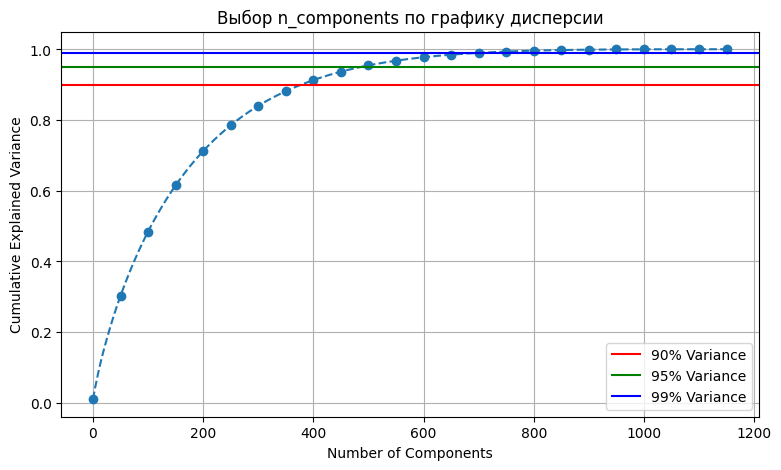

Чтобы сохранить 90% информации, нужно n_components = 380
Чтобы сохранить 95% информации, нужно n_components = 488
Чтобы сохранить 99% информации, нужно n_components = 705


In [32]:
# Анализ дисперсии
# Берём обучающие эмбеддинги последней эпохи
sw_train_last = swin_embs[-1]['train_emb']    
d2_train_last = dinov2_embs[-1]['train_emb'] 
concat_train_last = np.concatenate([sw_train_last, d2_train_last], axis=1)

# Обучаем PCA на все компоненты
pca_full = PCA(whiten=True)
pca_full.fit(concat_train_last)

# Кумулятивная объяснённая дисперсия
cumulative_variance = np.cumsum(pca_full.explained_variance_ratio_)

plt.figure(figsize=(9, 5))
plt.plot(cumulative_variance, marker='o', linestyle='--', markevery=50)
plt.axhline(y=0.90, color='r', linestyle='-', label='90% Variance')
plt.axhline(y=0.95, color='g', linestyle='-', label='95% Variance')
plt.axhline(y=0.99, color='b', linestyle='-', label='99% Variance')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('Выбор n_components по графику дисперсии')
plt.legend()
plt.grid(True)
plt.show()

for pct in [0.90, 0.95, 0.99]:
    n_comp = np.argmax(cumulative_variance >= pct) + 1
    print(f"Чтобы сохранить {pct*100:.0f}% информации, нужно n_components = {n_comp}")

In [33]:
# Ансамблирование (конкатенация + PCA) для каждой эпохи
results = []
for ep in range(EXP_EPOCHS):
    # Собираем эмбеддинги текущей эпохи
    sw_train = swin_embs[ep]['train_emb']   
    sw_val   = swin_embs[ep]['val_emb']     
    d2_train = dinov2_embs[ep]['train_emb'] 
    d2_val   = dinov2_embs[ep]['val_emb']
    labels_train = swin_embs[ep]['train_labels']
    labels_val   = swin_embs[ep]['val_labels']
    # Конкатенация
    concat_train = np.concatenate([sw_train, d2_train], axis=1)  # (N, 1152)
    concat_val   = np.concatenate([sw_val, d2_val], axis=1)

    # PCA
    pca = PCA(n_components=512, whiten=True)
    pca.fit(concat_train)
    emb_train = pca.transform(concat_train)
    emb_val   = pca.transform(concat_val)
    # Нормализация после PCA
    emb_train = F.normalize(torch.tensor(emb_train), p=2, dim=1).numpy()
    emb_val   = F.normalize(torch.tensor(emb_val), p=2, dim=1).numpy()

    # Метрики ансамбля на валидации
    val_metrics = compute_metrics_from_embeddings(emb_val, labels_val, recall_ks=[1], map_ks=[5])

    results.append({
        'epoch': ep+1,
        'val_recall@1': val_metrics['recall@1'],
        'val_map@5': val_metrics['map@5'],
        'val_simgap': val_metrics['gap']
    })

# Вывод итоговой таблицы
print("\n=== Ансамбль Swin + DINOv2 (конкатенация + PCA 512) ===")
for r in results:
    print(f"Epoch {r['epoch']}: Recall@1={r['val_recall@1']:.4f}, "
          f"mAP@5={r['val_map@5']:.4f}, SimGap={r['val_simgap']:.4f}")


=== Ансамбль Swin + DINOv2 (конкатенация + PCA 512) ===
Epoch 1: Recall@1=0.8454, mAP@5=0.8335, SimGap=0.5609
Epoch 2: Recall@1=0.8512, mAP@5=0.8400, SimGap=0.5614
Epoch 3: Recall@1=0.8531, mAP@5=0.8423, SimGap=0.5583


In [38]:
# Сохраняем результаты ансамбля в experiment_results.csv
ensemble_exp_name = 'swin_dinov2_pca512_ensemble'
old_df = load_results()
for r in results:
    row = {
        'experiment_name': ensemble_exp_name,
        'epoch': r['epoch'],
        'total_epochs': EXP_EPOCHS,
        'train_loss': None,             
        'val_recall@1': r['val_recall@1'],
        'val_map@5': r['val_map@5'],
        'val_simgap': r['val_simgap'],
        'training_time_sec': None    
    }
    old_df = pd.concat([old_df, pd.DataFrame([row])], ignore_index=True)
save_results(old_df)
print(f"Результаты ансамбля '{ensemble_exp_name}' сохранены в {Config.RESULTS_FILE}")

Результаты ансамбля 'swin_dinov2_pca512_ensemble' сохранены в experiment_results.csv


/tmp/ipykernel_1413/2711046699.py:15: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  old_df = pd.concat([old_df, pd.DataFrame([row])], ignore_index=True)


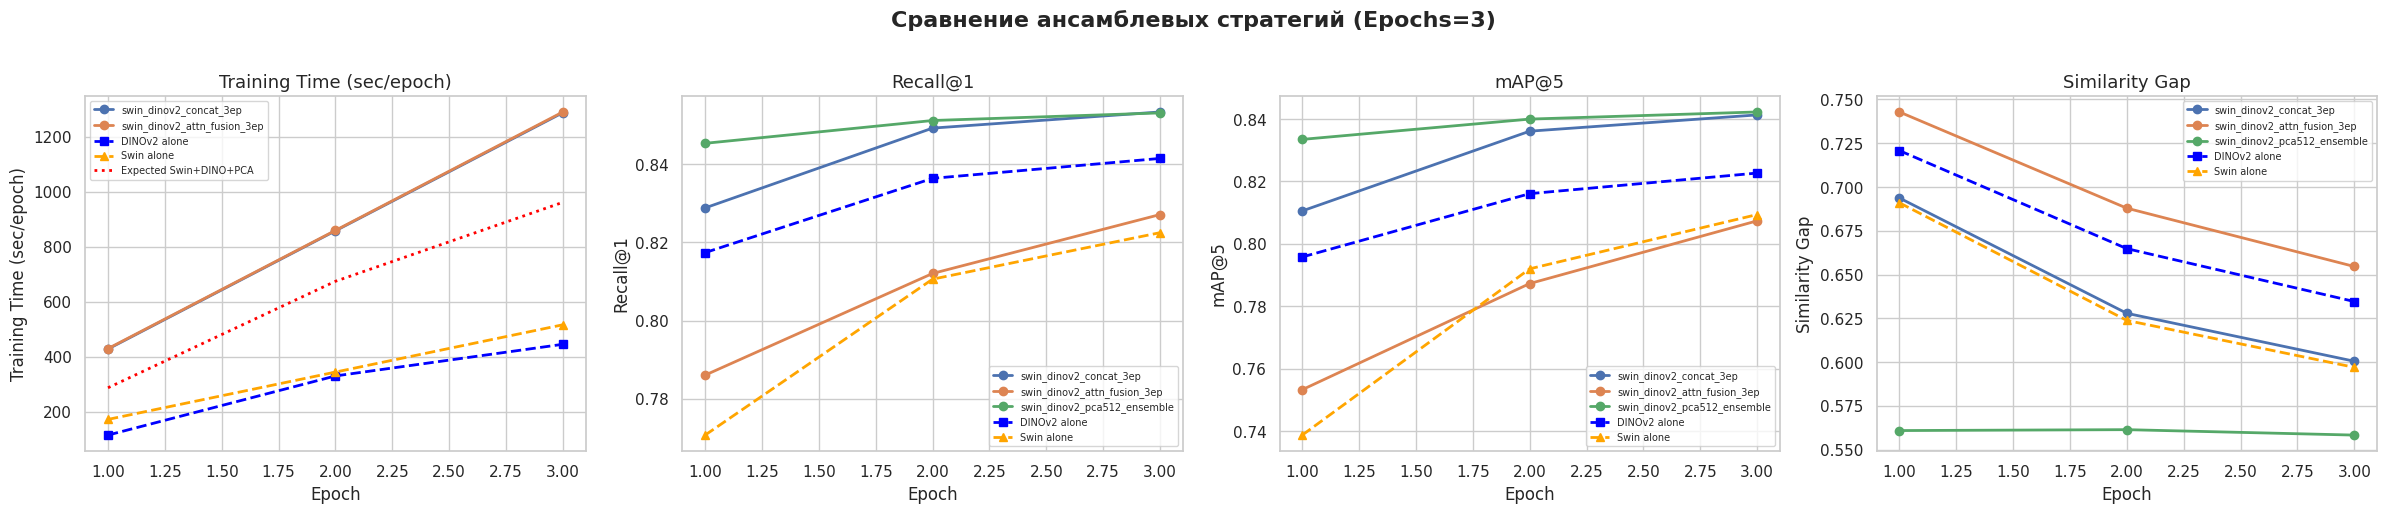

In [47]:
# Сравнение экспериментов concat, attn_fusion и ансамбля PCA + линии DINOv2 и Swin отдельно
# Значения отдельных моделей по эпохам (из логов)
dino_epochs = [1, 2, 3]
dino_recall = [0.8174, 0.8364, 0.8415]
dino_map    = [0.7958, 0.8161, 0.8227]
dino_gap    = [0.7208, 0.6648, 0.6346]
dino_time   = [115, 330, 445]          

swin_epochs = [1, 2, 3]
swin_recall = [0.7707, 0.8106, 0.8225]
swin_map    = [0.7387, 0.7920, 0.8094]
swin_gap    = [0.6910, 0.6238, 0.5970]
swin_time   = [172, 344, 516]           

EXP_EPOCHS = 3
target_experiments = [
    f'swin_dinov2_concat_{EXP_EPOCHS}ep',
    f'swin_dinov2_attn_fusion_{EXP_EPOCHS}ep',
    'swin_dinov2_pca512_ensemble'
]

df = load_results()
df_plot = df[df['experiment_name'].isin(target_experiments)].copy()

if df_plot.empty:
    print("Нет данных по указанным экспериментам.")
else:
    sns.set_theme(style="whitegrid")
    plt.rcParams.update({'font.size': 11, 'axes.labelsize': 12, 'axes.titlesize': 13})

    fig, axes = plt.subplots(1, 4, figsize=(24, 5))
    metrics = ['training_time_sec', 'val_recall@1', 'val_map@5', 'val_simgap']
    titles  = ['Training Time (sec/epoch)', 'Recall@1', 'mAP@5', 'Similarity Gap']

    for ax, metric, title in zip(axes, metrics, titles):
        # Отрисовка экспериментов
        for exp_name in target_experiments:
            exp_data = df_plot[df_plot['experiment_name'] == exp_name].sort_values('epoch')
            if exp_data.empty or exp_data[metric].isna().all():
                continue
            ax.plot(exp_data['epoch'], exp_data[metric],
                    marker='o', linewidth=2, label=exp_name)

        # Линии отдельных моделей DINOv2 и Swin
        if metric == 'val_recall@1':
            ax.plot(dino_epochs, dino_recall, 's--', color='blue', linewidth=2, label='DINOv2 alone')
            ax.plot(swin_epochs, swin_recall, '^--', color='orange', linewidth=2, label='Swin alone')
        elif metric == 'val_map@5':
            ax.plot(dino_epochs, dino_map, 's--', color='blue', linewidth=2, label='DINOv2 alone')
            ax.plot(swin_epochs, swin_map, '^--', color='orange', linewidth=2, label='Swin alone')
        elif metric == 'val_simgap':
            ax.plot(dino_epochs, dino_gap, 's--', color='blue', linewidth=2, label='DINOv2 alone')
            ax.plot(swin_epochs, swin_gap, '^--', color='orange', linewidth=2, label='Swin alone')
        elif metric == 'training_time_sec':
            ax.plot(dino_epochs, dino_time, 's--', color='blue', linewidth=2, label='DINOv2 alone')
            ax.plot(swin_epochs, swin_time, '^--', color='orange', linewidth=2, label='Swin alone')
            # Ожидаемое время ансамбля с PCA
            sum_time = [s + d for s, d in zip(swin_time, dino_time)]
            ax.plot(swin_epochs, sum_time, ':', color='red', linewidth=2, label='Expected Swin+DINO+PCA')

        ax.set_xlabel('Epoch')
        ax.set_ylabel(title)
        ax.set_title(title)
        ax.legend(fontsize=7)
        ax.grid(True)

    plt.suptitle(f'Сравнение ансамблевых стратегий (Epochs={EXP_EPOCHS})', y=1.02, fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.show()

### Ансамблирование даёт малый прирост метрик (порядка 1%) при кратных затратах на обучение.
---

### Optuna

In [29]:
OPTUNA_EPOCHS = 5
WARMUP_EPOCHS = 3
TRIALS = 20

In [30]:
class OptunaTrainer(Trainer):
    """Trainer с интеграцией Optuna: передаёт промежуточные метрики и поддерживает pruning."""
    def __init__(self, model, loss_func, optimizer, experiment_name,
                 scheduler=None, optuna_trial: optuna.Trial = None):
        super().__init__(model, loss_func, optimizer, experiment_name, scheduler=scheduler)
        self.optuna_trial = optuna_trial

    def train(self, train_loader, val_loader, max_epochs):
        self.train_loader = train_loader
        self.val_loader = val_loader
        self.max_epochs = max_epochs
        start = time.time()
        for ep in range(max_epochs):
            self._run_epoch(ep)
            self.validate(ep)
            self.training_time = time.time() - start

            # Сохраняем результат каждой эпохи
            self.save_results(epoch=ep+1)
            
            # Сообщаем промежуточную метрику в Optuna
            if self.optuna_trial is not None:
                current_map = self.history['val_map5'][-1]
                self.optuna_trial.report(current_map, step=ep)
                if self.optuna_trial.should_prune():
                    raise optuna.TrialPruned()

            if self.scheduler is not None:
                self.scheduler.step()

        self.training_time = time.time() - start

In [31]:
def objective(trial):
    backbone_lr = trial.suggest_categorical('backbone_lr', [1e-5, 2e-5, 4e-5, 8e-5])
    head_lr = trial.suggest_categorical('head_lr', [5e-3,1e-2, 2e-2, 4e-2])
    margin = trial.suggest_float('margin', 28, 30, step=0.5)

    print(f"Trial {trial.number}: backbone_lr={backbone_lr:.2e}, proj_lr={head_lr:.2e}, margin={margin}")
    
    exp_name = f"optuna_trial_{trial.number}"

    # Модель: DINOv2 unfrozen 4 блока
    model = DinoWithProjectorUnfrozen(unfreeze_blocks=4).to(Config.DEVICE)

    # Loss с предложенным margin
    loss_func = losses.ArcFaceLoss(
        num_classes=num_classes,
        embedding_size=384,
        margin=margin,
        scale = Config.ARC_SCALE,
    ).to(Config.DEVICE)

    # Оптимизатор с раздельными lr
    unfrozen_backbone_params = [p for p in model.backbone.parameters() if p.requires_grad]
    optimizer = torch.optim.AdamW([
        {'params': unfrozen_backbone_params, 'lr': backbone_lr, 'weight_decay': back_weight_decay},
        {'params': model.proj.parameters(),  'lr': head_lr,     'weight_decay': Config.WEIGHT_DECAY},
        {'params': loss_func.parameters(),   'lr': head_lr,     'weight_decay': 0.0}])

    # Планировщик: 1 эпохи warmup, затем косинус до 1e-6
    warmup = torch.optim.lr_scheduler.LinearLR(optimizer, start_factor=0.01, end_factor=1.0, total_iters=1)
    cosine = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=OPTUNA_EPOCHS - 1,eta_min=1e-6)
    scheduler = torch.optim.lr_scheduler.SequentialLR(optimizer,schedulers=[warmup, cosine],milestones=[1])

    # Trainer с Optuna-интеграцией
    trainer = OptunaTrainer(model, loss_func, optimizer, exp_name,
                            scheduler=scheduler, optuna_trial=trial)
    try:
        trainer.train(train_strong_loader, val_loader, OPTUNA_EPOCHS)
    except optuna.TrialPruned:
        # Если trial прерван, всё равно возвращаем лучший map из истории
        best_map = max(trainer.history['val_map5']) if trainer.history['val_map5'] else 0.0
        # Очистка перед выходом
        del model, loss_func, optimizer, scheduler, trainer
        gc.collect(); torch.cuda.empty_cache()
        return best_map

    best_map = max(trainer.history['val_map5'])
    # Очистка
    del model, loss_func, optimizer, scheduler, trainer
    gc.collect(); torch.cuda.empty_cache()
    return best_map

In [32]:
study = optuna.create_study(
    direction='maximize',
    sampler=TPESampler(seed=Config.SEED),
    pruner=MedianPruner(n_startup_trials=OPTUNA_EPOCHS, n_warmup_steps=WARMUP_EPOCHS)  # не прерывать раньше 3-й эпохи
)

study.optimize(objective, n_trials=TRIALS, catch=(RuntimeError,))

print("=== Лучшие параметры ===")
print(f"Trial: {study.best_trial.number}")
print(f"Best mAP@5: {study.best_value:.4f}")
for k, v in study.best_params.items():
    print(f"  {k}: {v}")

[I 2026-05-21 02:47:37,920] A new study created in memory with name: no-name-88fce529-c7f4-42ea-ad4b-152c1399f26b


Trial 0: backbone_lr=2.00e-05, proj_lr=4.00e-02, margin=29.5


model.safetensors:   0%|          | 0.00/88.2M [00:00<?, ?B/s]

Epoch 1/5: 100%|██████████| 152/152 [02:19<00:00,  1.09it/s, loss=25.1]
Epoch 1 | Train Loss: 25.5008
Epoch 1 | mAP@5: 0.7444 | Val Recall@1: 0.7751 | SimGap: 0.6941
Epoch 2/5: 100%|██████████| 152/152 [02:10<00:00,  1.17it/s, loss=18.5]
Epoch 2 | Train Loss: 20.8818
Epoch 2 | mAP@5: 0.8162 | Val Recall@1: 0.8342 | SimGap: 0.6641
Epoch 3/5: 100%|██████████| 152/152 [02:08<00:00,  1.18it/s, loss=11.8]
Epoch 3 | Train Loss: 12.4132
Epoch 3 | mAP@5: 0.8275 | Val Recall@1: 0.8442 | SimGap: 0.6234
Epoch 4/5: 100%|██████████| 152/152 [02:09<00:00,  1.18it/s, loss=8.14]
Epoch 4 | Train Loss: 7.2677
Epoch 4 | mAP@5: 0.8329 | Val Recall@1: 0.8500 | SimGap: 0.6123
Epoch 5/5: 100%|██████████| 152/152 [02:08<00:00,  1.18it/s, loss=4.36]
Epoch 5 | Train Loss: 4.7228
Epoch 5 | mAP@5: 0.8325 | Val Recall@1: 0.8473 | SimGap: 0.6073


[I 2026-05-21 03:05:17,374] Trial 0 finished with value: 0.8328693573223113 and parameters: {'backbone_lr': 2e-05, 'head_lr': 0.04, 'margin': 29.5}. Best is trial 0 with value: 0.8328693573223113.


...

Trial 18: backbone_lr=8.00e-05, proj_lr=1.00e-02, margin=28.5
Epoch 1/5: 100%|██████████| 152/152 [02:10<00:00,  1.17it/s, loss=25.1]
Epoch 1 | Train Loss: 25.4977
Epoch 1 | mAP@5: 0.7477 | Val Recall@1: 0.7749 | SimGap: 0.6859
Epoch 2/5: 100%|██████████| 152/152 [02:13<00:00,  1.14it/s, loss=20.3]
Epoch 2 | Train Loss: 22.0520
Epoch 2 | mAP@5: 0.7921 | Val Recall@1: 0.8157 | SimGap: 0.6908
Epoch 3/5: 100%|██████████| 152/152 [02:12<00:00,  1.15it/s, loss=17.4]
Epoch 3 | Train Loss: 16.7291
Epoch 3 | mAP@5: 0.8097 | Val Recall@1: 0.8303 | SimGap: 0.6381
Epoch 4/5: 100%|██████████| 152/152 [02:11<00:00,  1.16it/s, loss=12.4]
Epoch 4 | Train Loss: 12.8033
Epoch 4 | mAP@5: 0.8116 | Val Recall@1: 0.8322 | SimGap: 0.6189


[I 2026-05-21 07:47:41,219] Trial 18 finished with value: 0.8115536105032823 and parameters: {'backbone_lr': 8e-05, 'head_lr': 0.01, 'margin': 28.5}. Best is trial 13 with value: 0.8368842693897398.


Trial 19: backbone_lr=4.00e-05, proj_lr=4.00e-02, margin=29.5
Epoch 1/5: 100%|██████████| 152/152 [02:09<00:00,  1.18it/s, loss=24.7]
Epoch 1 | Train Loss: 25.5173
Epoch 1 | mAP@5: 0.7464 | Val Recall@1: 0.7783 | SimGap: 0.7014
Epoch 2/5: 100%|██████████| 152/152 [02:09<00:00,  1.17it/s, loss=17.4]
Epoch 2 | Train Loss: 20.8736
Epoch 2 | mAP@5: 0.8203 | Val Recall@1: 0.8390 | SimGap: 0.6459
Epoch 3/5: 100%|██████████| 152/152 [02:09<00:00,  1.18it/s, loss=12.1]
Epoch 3 | Train Loss: 12.3935
Epoch 3 | mAP@5: 0.8287 | Val Recall@1: 0.8446 | SimGap: 0.6308
Epoch 4/5: 100%|██████████| 152/152 [02:09<00:00,  1.17it/s, loss=6.09]
Epoch 4 | Train Loss: 7.0411
Epoch 4 | mAP@5: 0.8355 | Val Recall@1: 0.8497 | SimGap: 0.6169
Epoch 5/5: 100%|██████████| 152/152 [02:09<00:00,  1.17it/s, loss=4.67]
Epoch 5 | Train Loss: 4.3455
Epoch 5 | mAP@5: 0.8360 | Val Recall@1: 0.8493 | SimGap: 0.6114


[I 2026-05-21 08:05:05,718] Trial 19 finished with value: 0.8359737417943106 and parameters: {'backbone_lr': 4e-05, 'head_lr': 0.04, 'margin': 29.5}. Best is trial 13 with value: 0.8368842693897398.


=== Лучшие параметры ===
Trial: 13
Best mAP@5: 0.8369
  backbone_lr: 4e-05
  head_lr: 0.04
  margin: 28.5
